In [9]:
import importlib
import sys
from pathlib import Path

import pandas as pd

cwd = Path.cwd().resolve()
if cwd.name == 'Task3':
    repo_root = cwd.parent
elif cwd.name == 'Notebooks':
    repo_root = cwd.parent
else:
    repo_root = cwd

if not (repo_root / 'Task3').exists():
    raise RuntimeError('Could not locate the repository root from the current working directory.')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

package_module = importlib.import_module('Task3')
io_module = importlib.import_module('Task3.data.io')
parsing_module = importlib.import_module('Task3.data.parsing')
summaries_module = importlib.import_module('Task3.analysis.summaries')
full_analysis_module = importlib.import_module('Task3.analysis.full_analysis')
ci_visualizations_module = importlib.import_module('Task3.analysis.ci_visualizations')

io_module = importlib.reload(io_module)
parsing_module = importlib.reload(parsing_module)
summaries_module = importlib.reload(summaries_module)
full_analysis_module = importlib.reload(full_analysis_module)
ci_visualizations_module = importlib.reload(ci_visualizations_module)
package_module = importlib.reload(package_module)

get_repo_and_outputs_root = io_module.get_repo_and_outputs_root
find_report_files = io_module.find_report_files
load_batch_dataframe = parsing_module.load_batch_dataframe
summarize_by_family = summaries_module.summarize_by_family
compute_baseline_deltas = summaries_module.compute_baseline_deltas
show_top_worst = summaries_module.show_top_worst
plot_metric_bars = summaries_module.plot_metric_bars
plot_experiment_confidence_intervals = ci_visualizations_module.plot_experiment_confidence_intervals
run_full_perturbation_analysis = full_analysis_module.run_full_perturbation_analysis

REPO_ROOT, OUTPUTS_ROOT = get_repo_and_outputs_root()
pd.set_option('display.max_colwidth', 120)


In [10]:
BATCH_NAME = 'seed_01'  # change this
REPORT_SUFFIX = 'cifar10_perturbation_tests_CI_Angelos'

report_files = find_report_files(OUTPUTS_ROOT, BATCH_NAME, REPORT_SUFFIX)
print('Reports found:', len(report_files))
for p in report_files:
    print('-', p.name)

if not report_files:
    raise FileNotFoundError(f'No reports found for BATCH_NAME={BATCH_NAME!r} under {OUTPUTS_ROOT}')


Reports found: 1
- seed_01_ddpm_cifar10_perturbation_tests_CI_Angelos.json


In [11]:
df = load_batch_dataframe(report_files)
#df[['name', 'model', 'dataset', 'perturbation_family', 'status', 'metrics_available']].head(8)


Rows loaded: 213
Columns: 76


,experiments,rows,successful_rows,with_metrics,fid_mean,is_mean,precision_mean,recall_mean
perturbation_family,,,,,,,,
class_imbalance,132,132,132,132,28.605163,7.004673,0.808665,0.708469
class_removal,22,22,22,22,29.902945,6.944534,0.808381,0.699183
preprocessing,21,21,21,21,110.815440,4.221622,0.660119,0.289100
sample_size,9,9,9,9,127.876877,4.841428,0.843663,0.751787
memoisation,7,7,7,7,22.129378,7.485795,0.836942,0.785156
degradation_noise,5,5,5,5,207.977918,3.011896,0.424531,0.136250
degradation_all,5,5,5,5,252.158578,2.153673,0.480312,0.059375
degradation_blur,5,5,5,5,211.756609,2.395945,0.379062,0.084062
degradation_jpeg,5,5,5,5,111.783007,4.294952,0.628125,0.328906


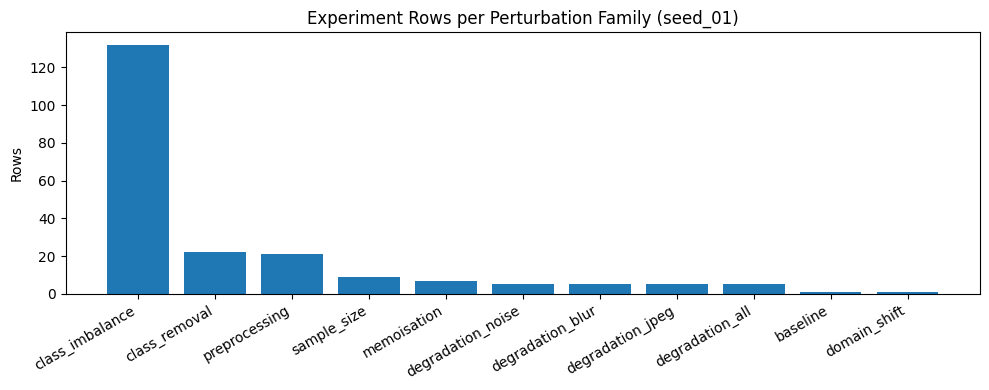

In [12]:
family_summary = summarize_by_family(df, BATCH_NAME)
#family_summary


In [13]:
df_delta, delta_summary = compute_baseline_deltas(df)
#delta_summary


,fid_delta,kid_mean_delta,is_mean_delta,precision_delta,recall_delta,density_delta,coverage_delta
perturbation_family,,,,,,,
baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
class_imbalance,0.262601,0.000271,-0.160535,0.008665,-0.010281,0.034504,0.017910
class_removal,1.560383,0.001323,-0.220674,0.008381,-0.019567,0.040781,0.004865
degradation_all,223.816016,0.313169,-5.011535,-0.319688,-0.659375,-0.592469,-0.725313
degradation_blur,183.414047,0.200543,-4.769263,-0.420938,-0.634687,-0.693125,-0.713125
degradation_jpeg,83.440445,0.116884,-2.870256,-0.171875,-0.389844,-0.384563,-0.454688
degradation_noise,179.635356,0.202722,-4.153312,-0.375469,-0.582500,-0.754469,-0.697969
domain_shift,248.644819,0.241495,0.000000,-0.800000,-0.503125,-0.970938,-0.877344
memoisation,-6.213184,-0.002021,0.320587,0.036942,0.066406,0.010022,0.053348


In [ ]:
#show_top_worst(df_delta)


In [ ]:
plot_metric_bars(df_delta)


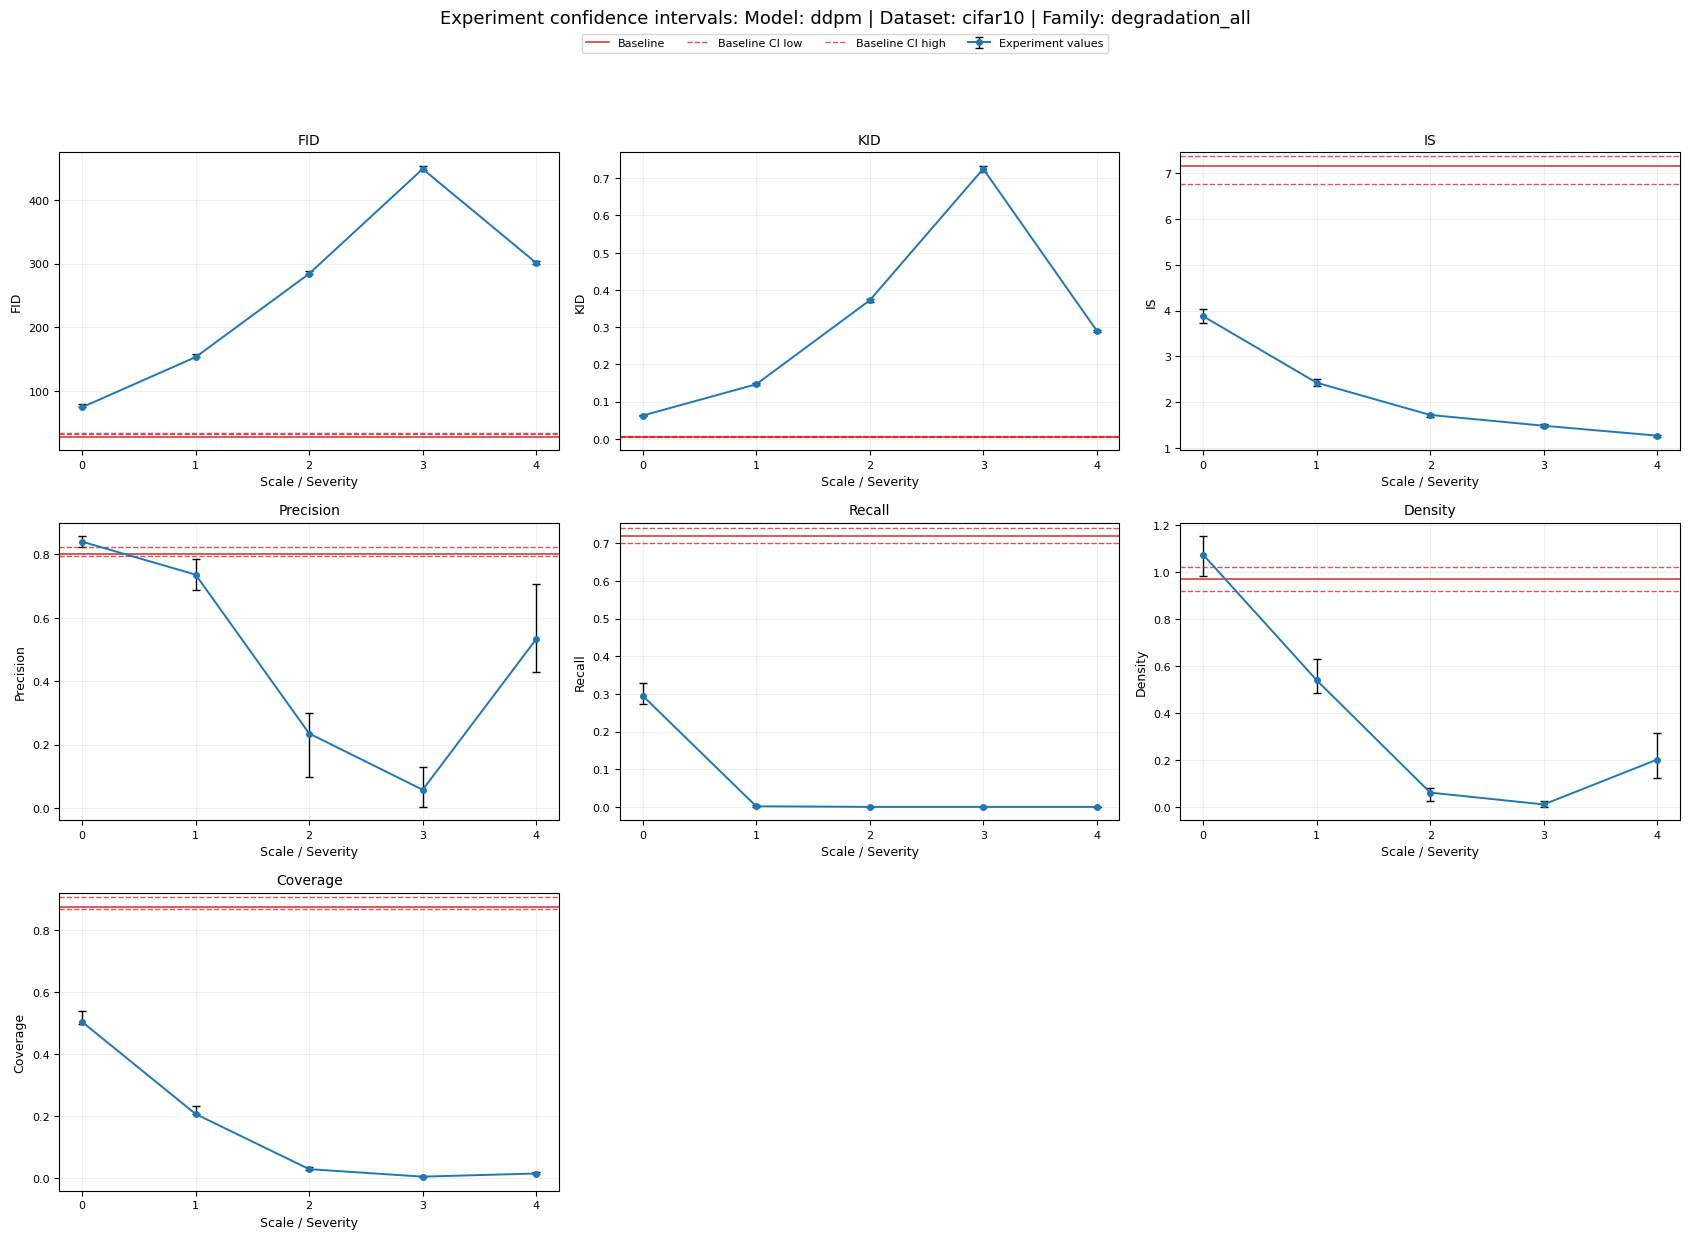

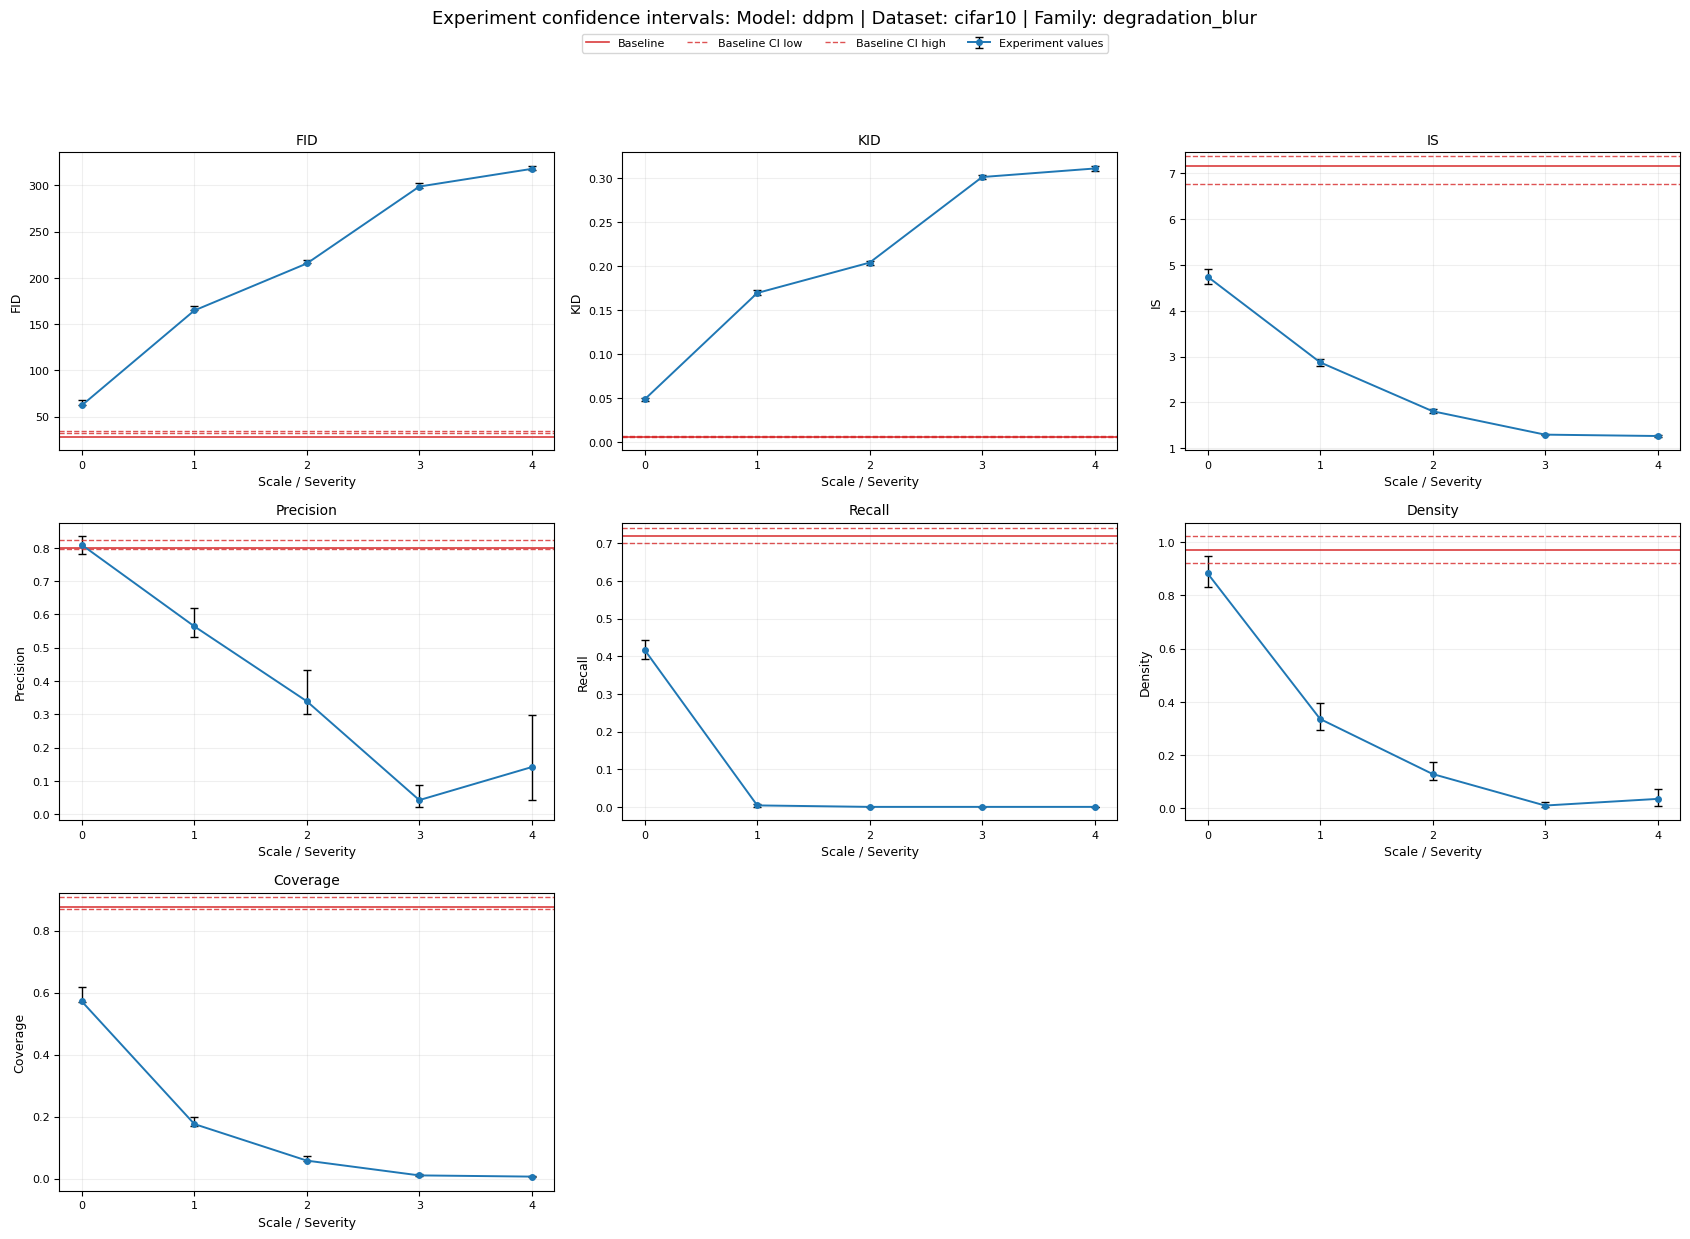

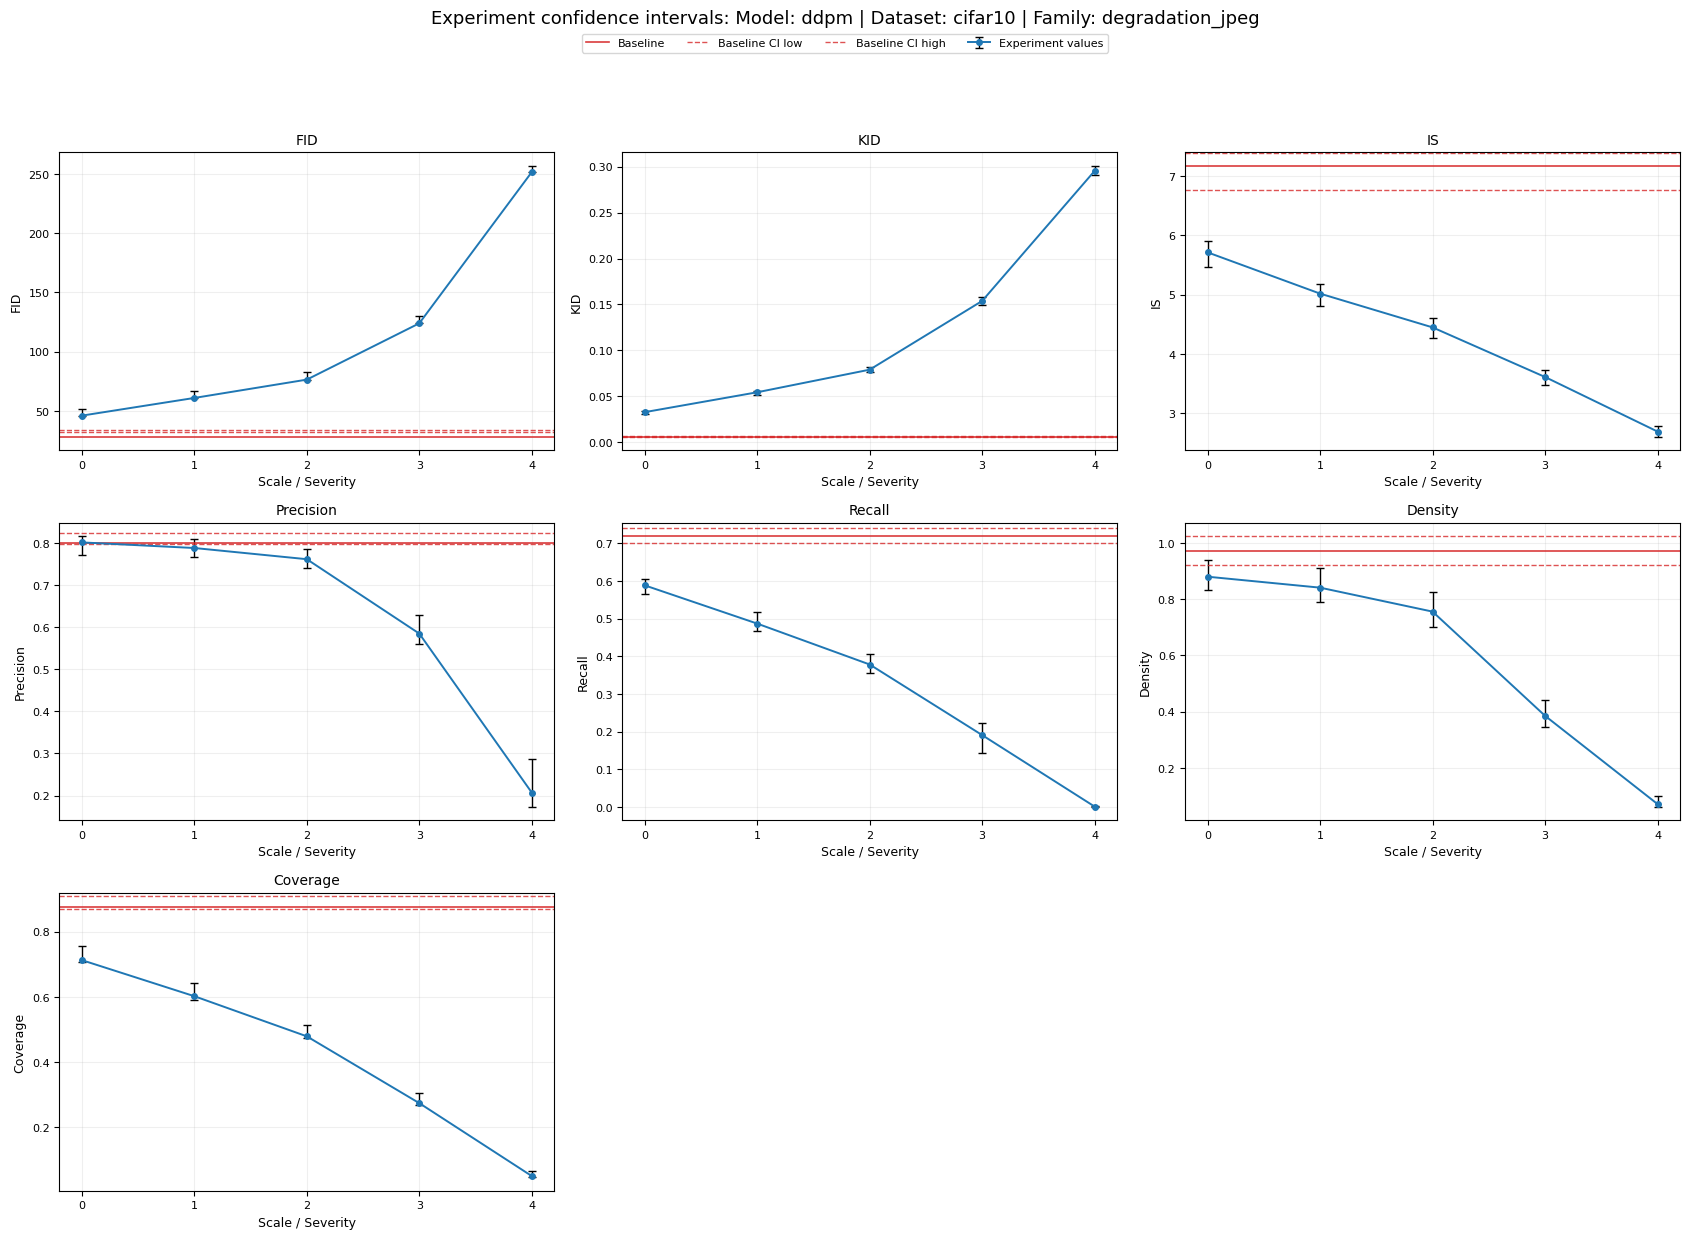

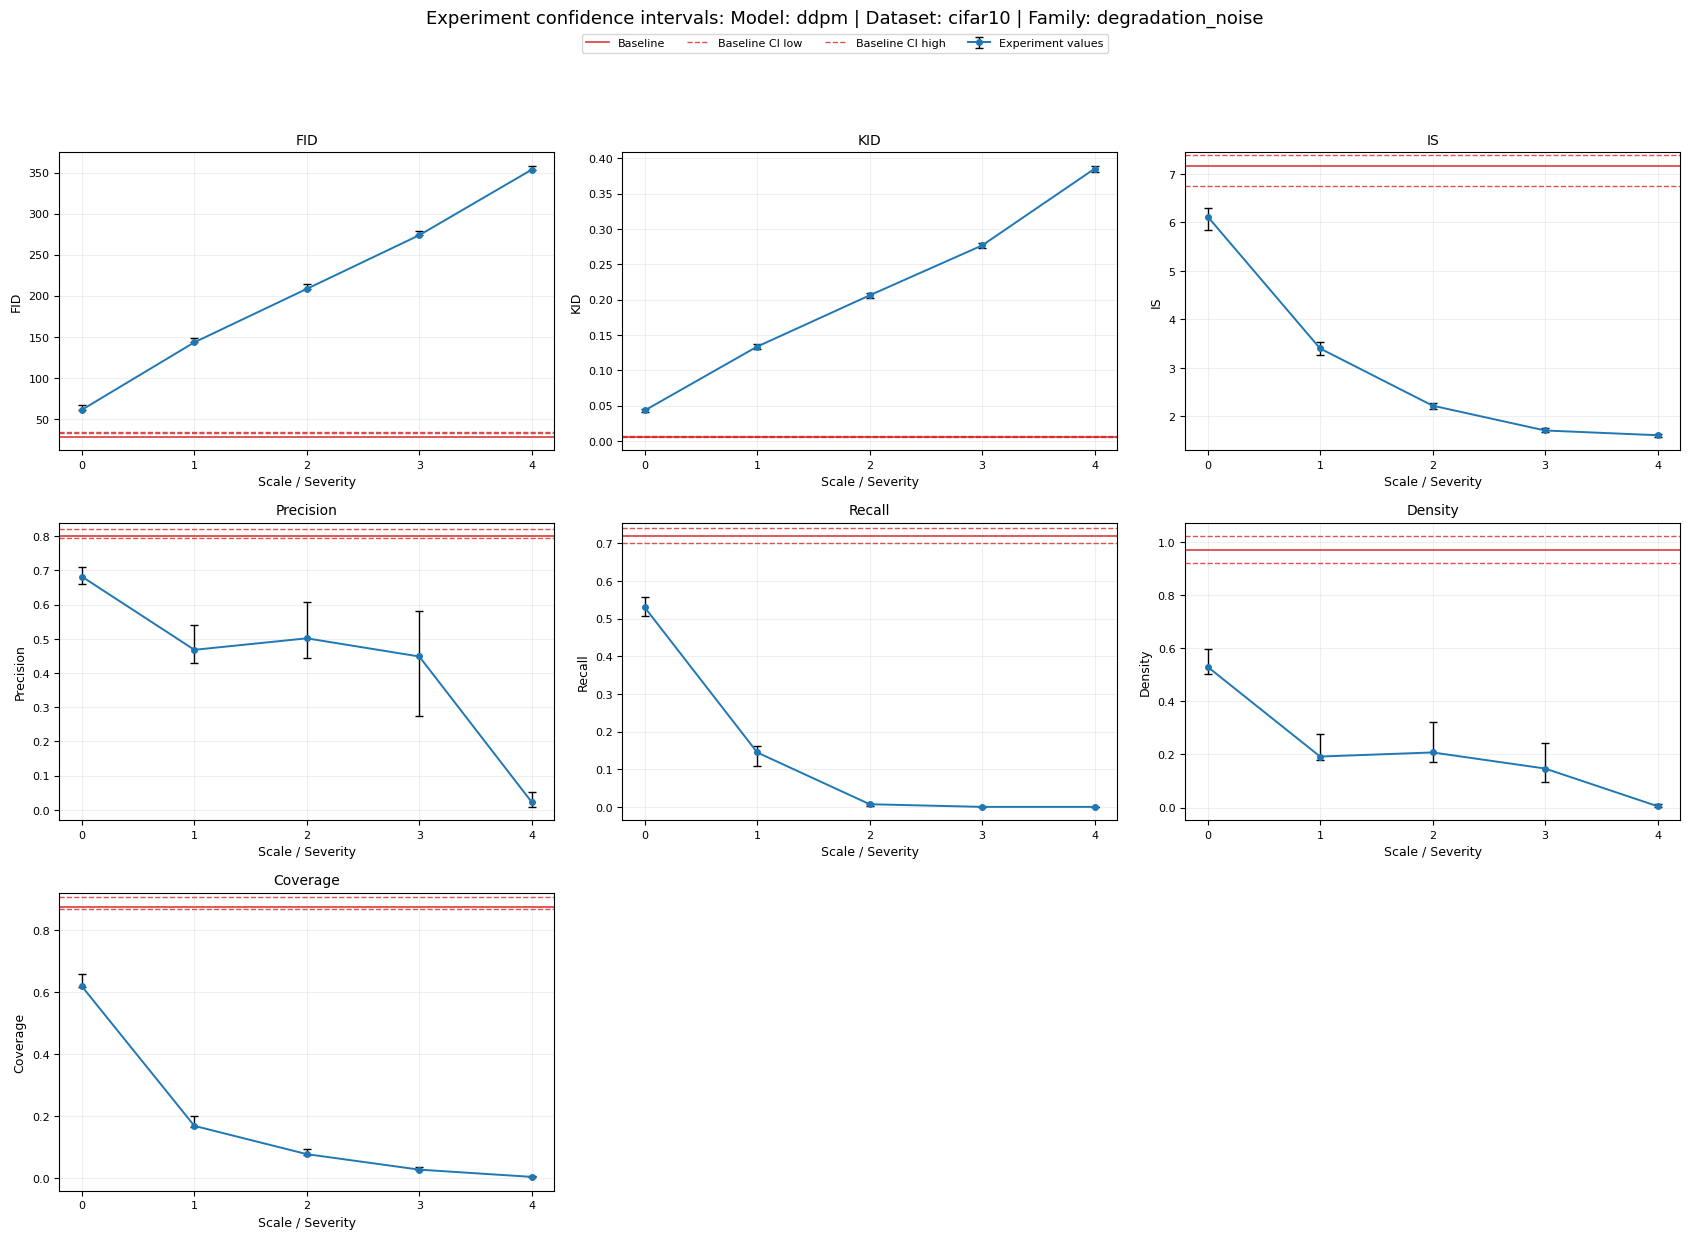

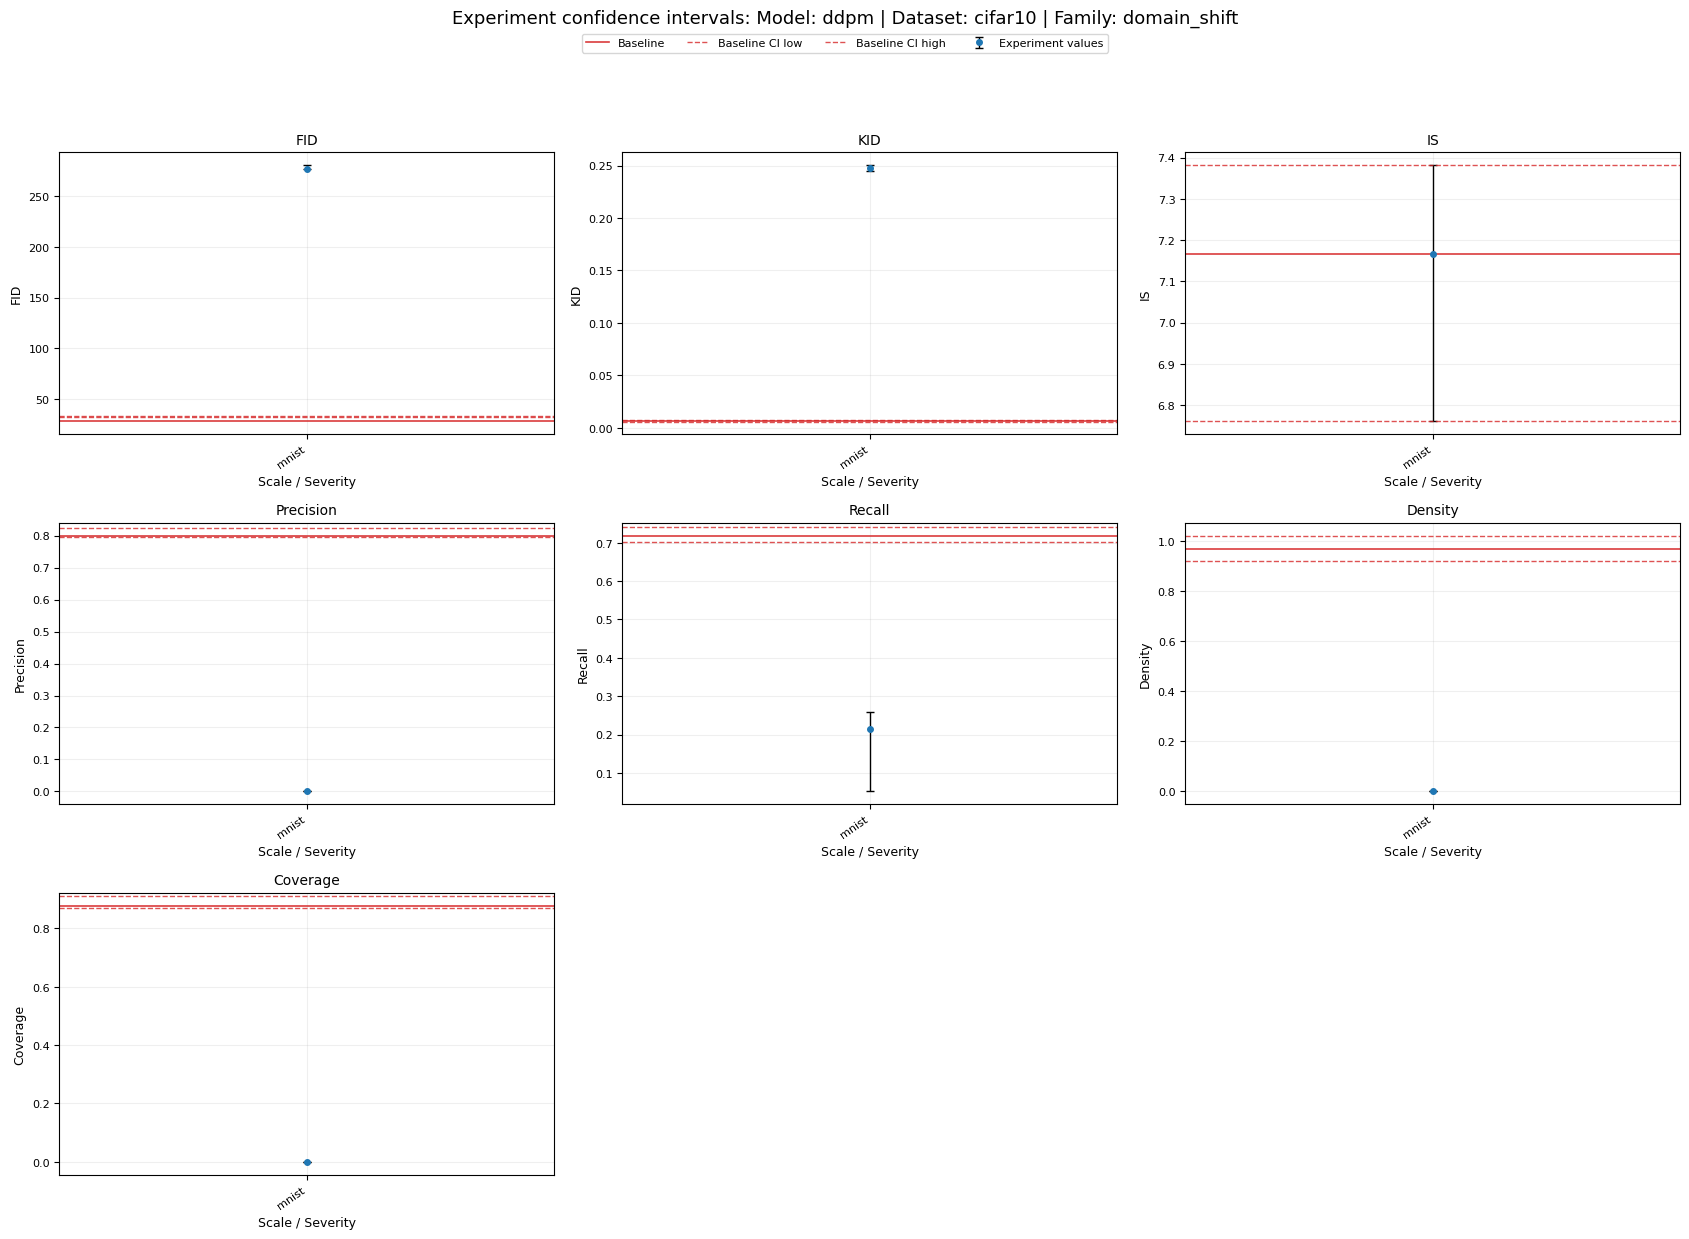

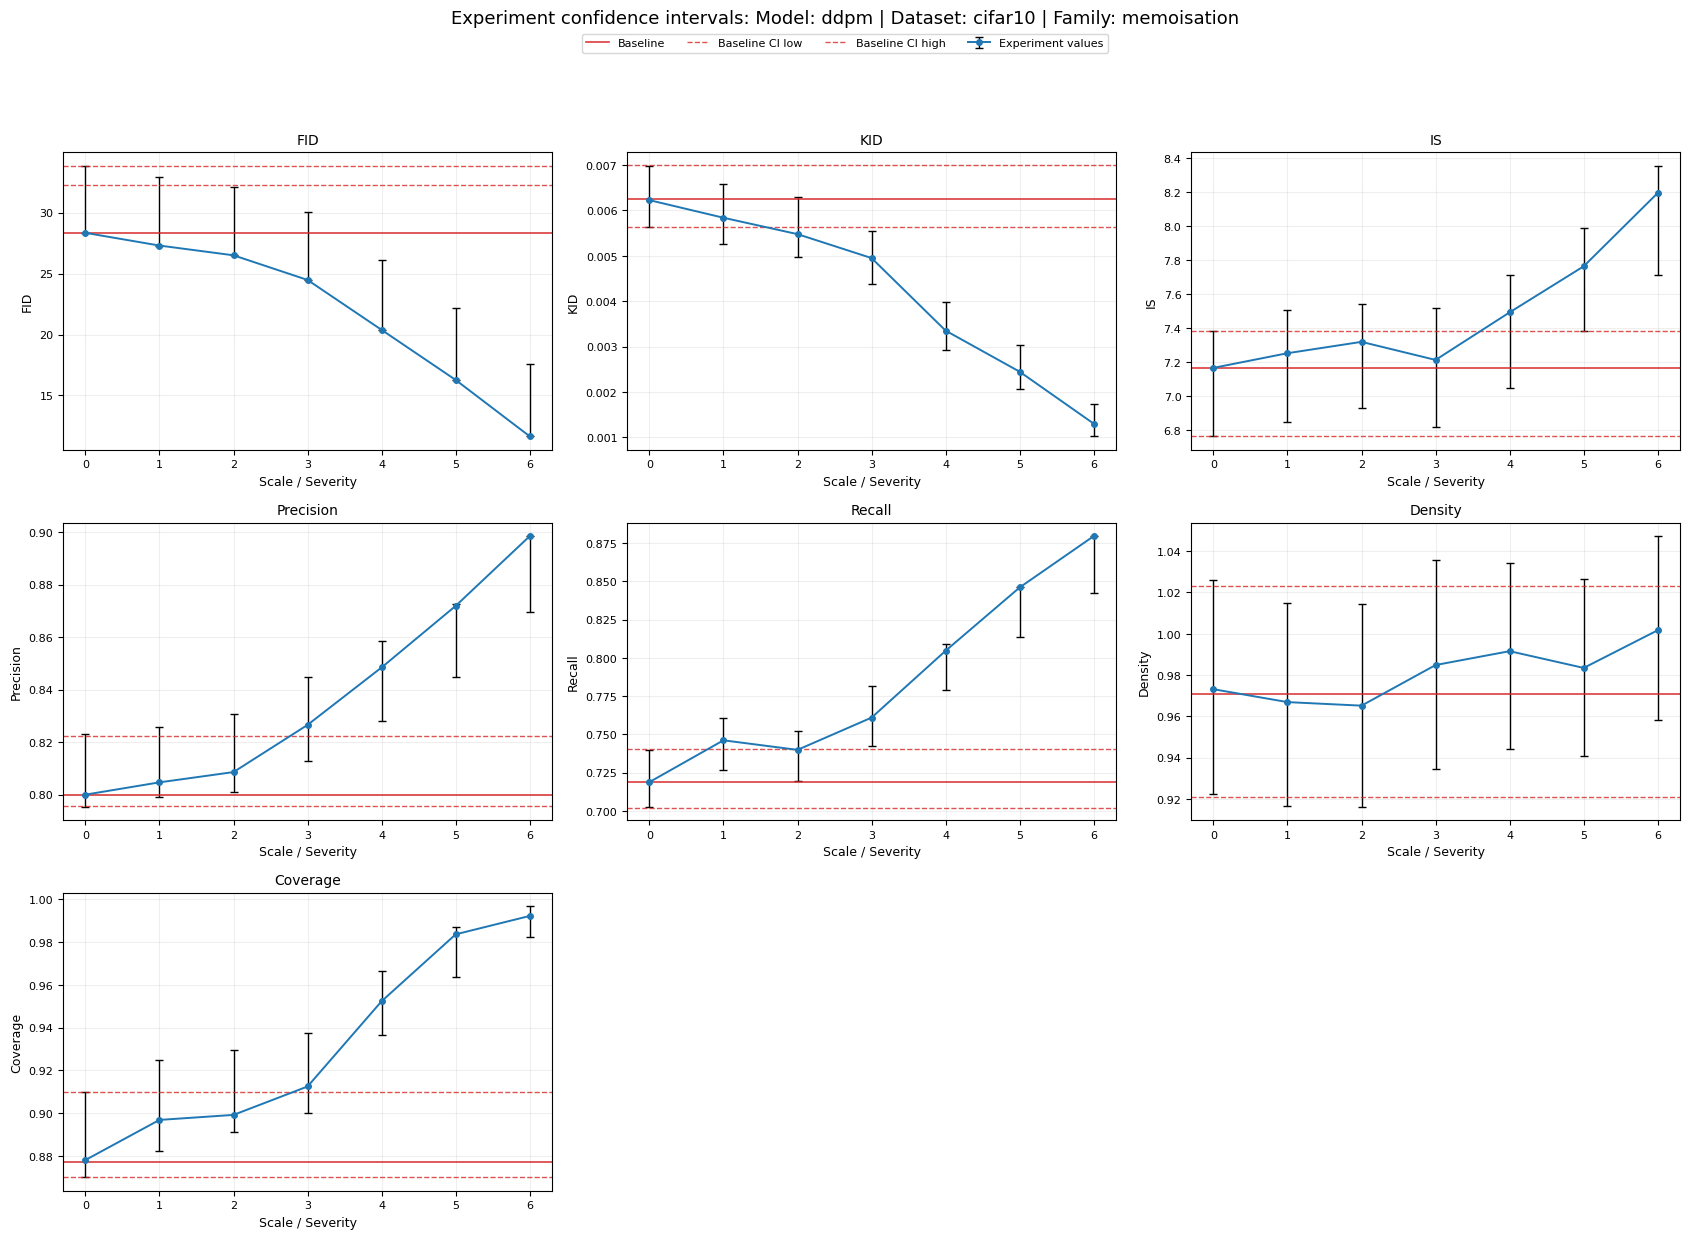

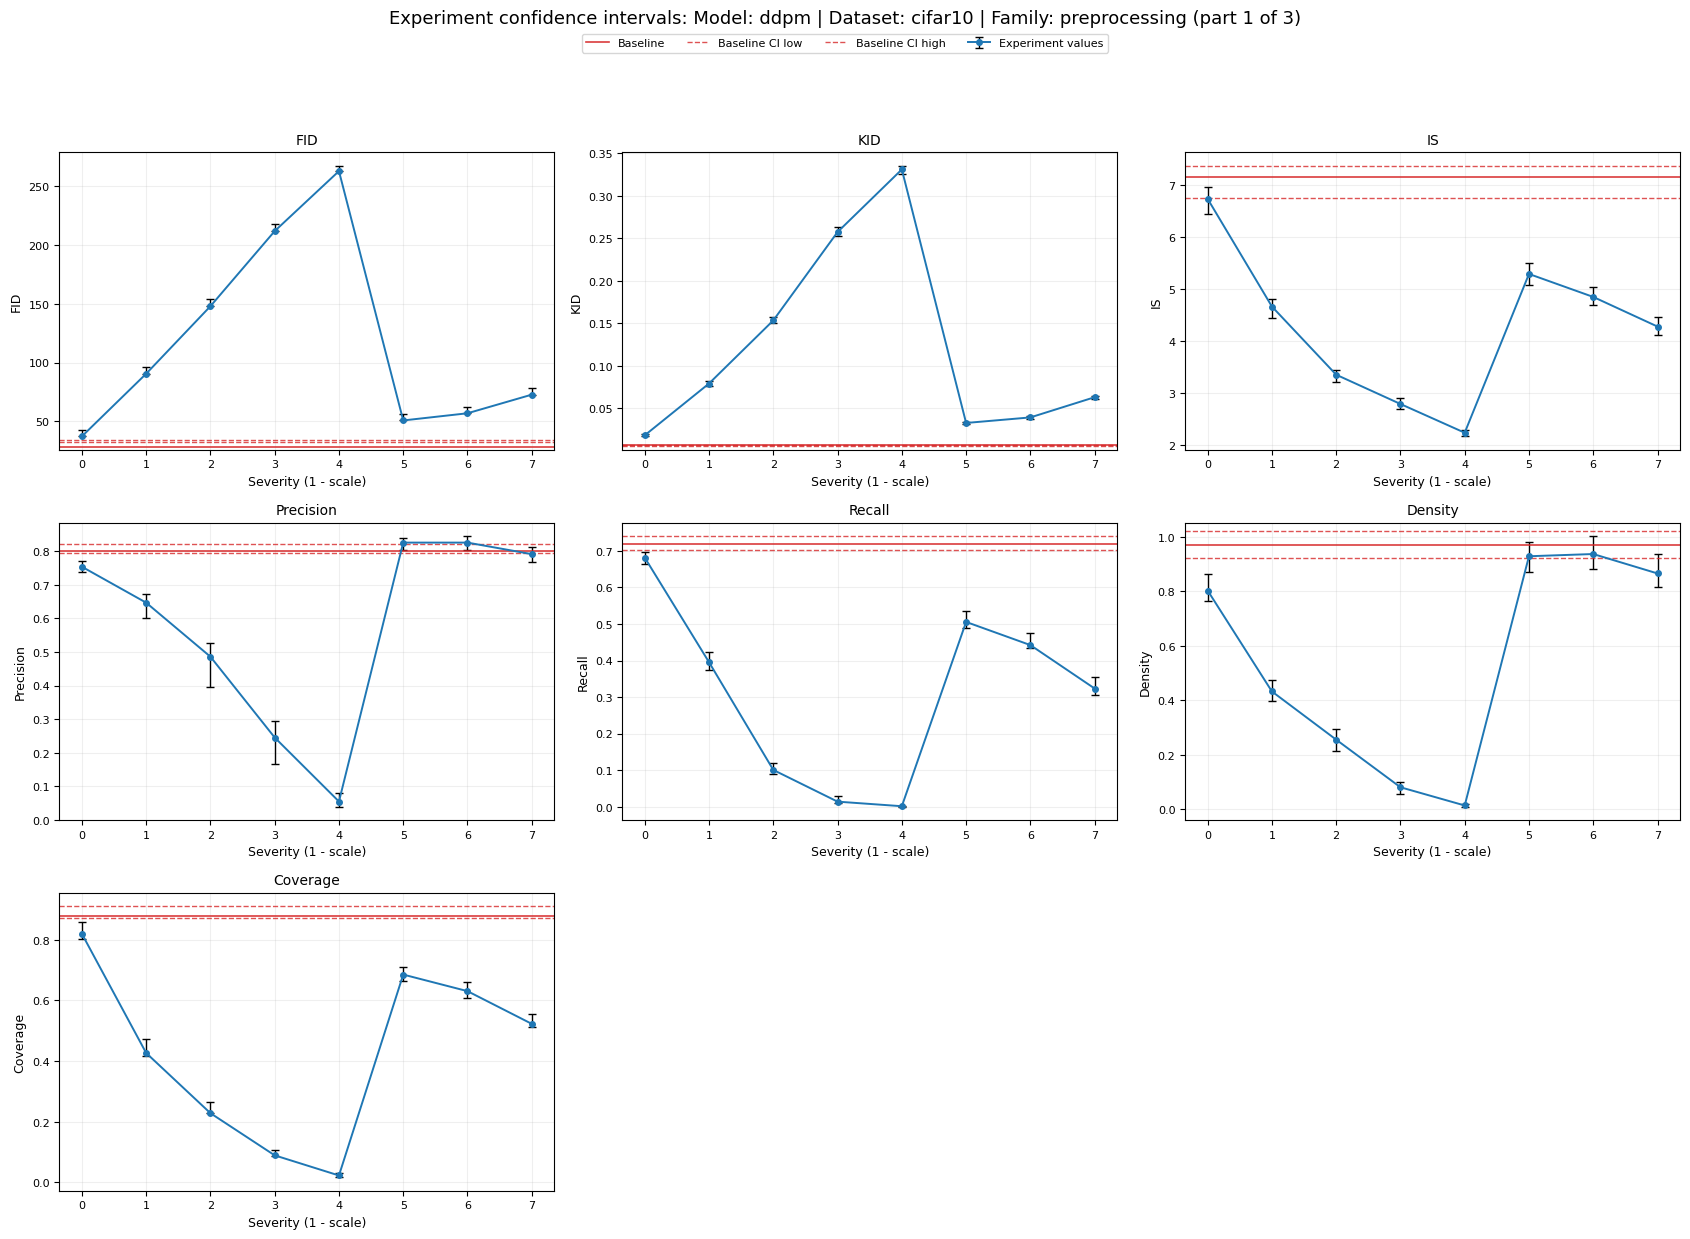

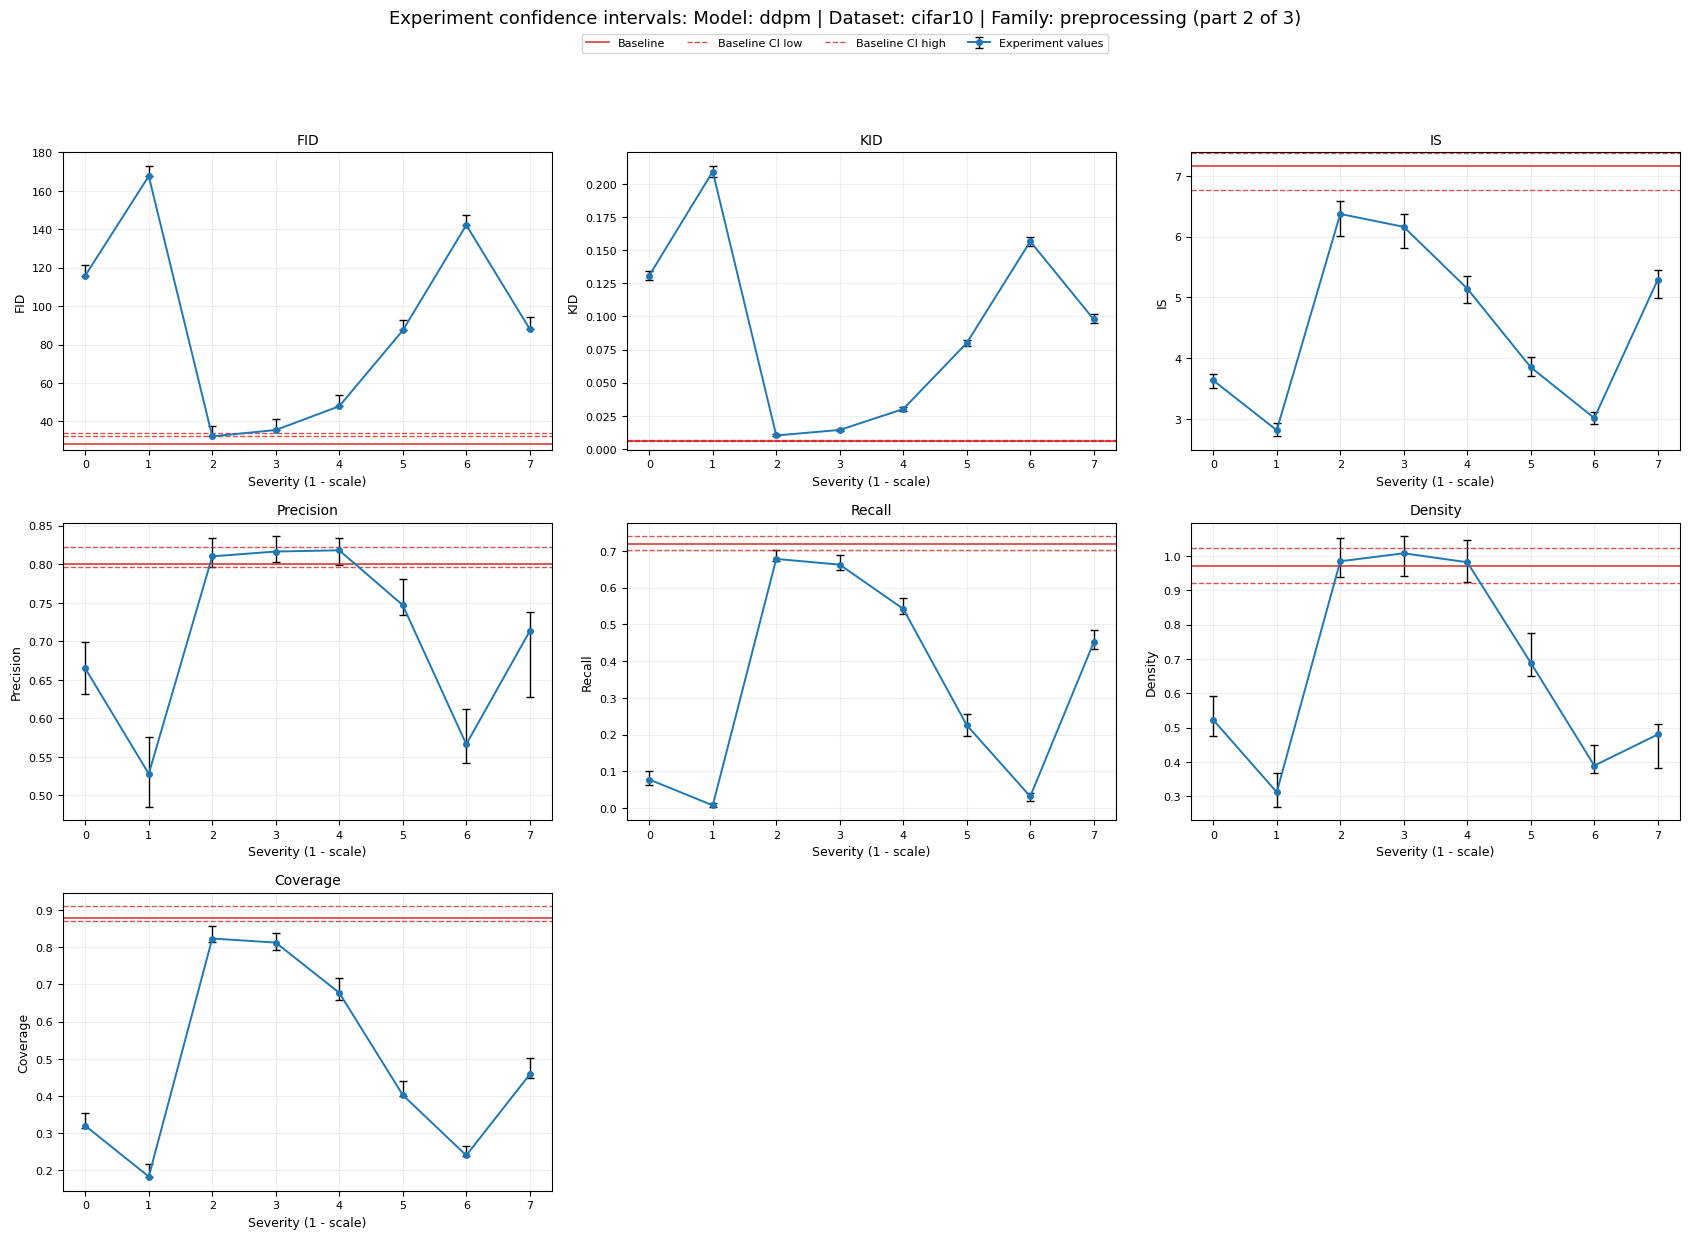

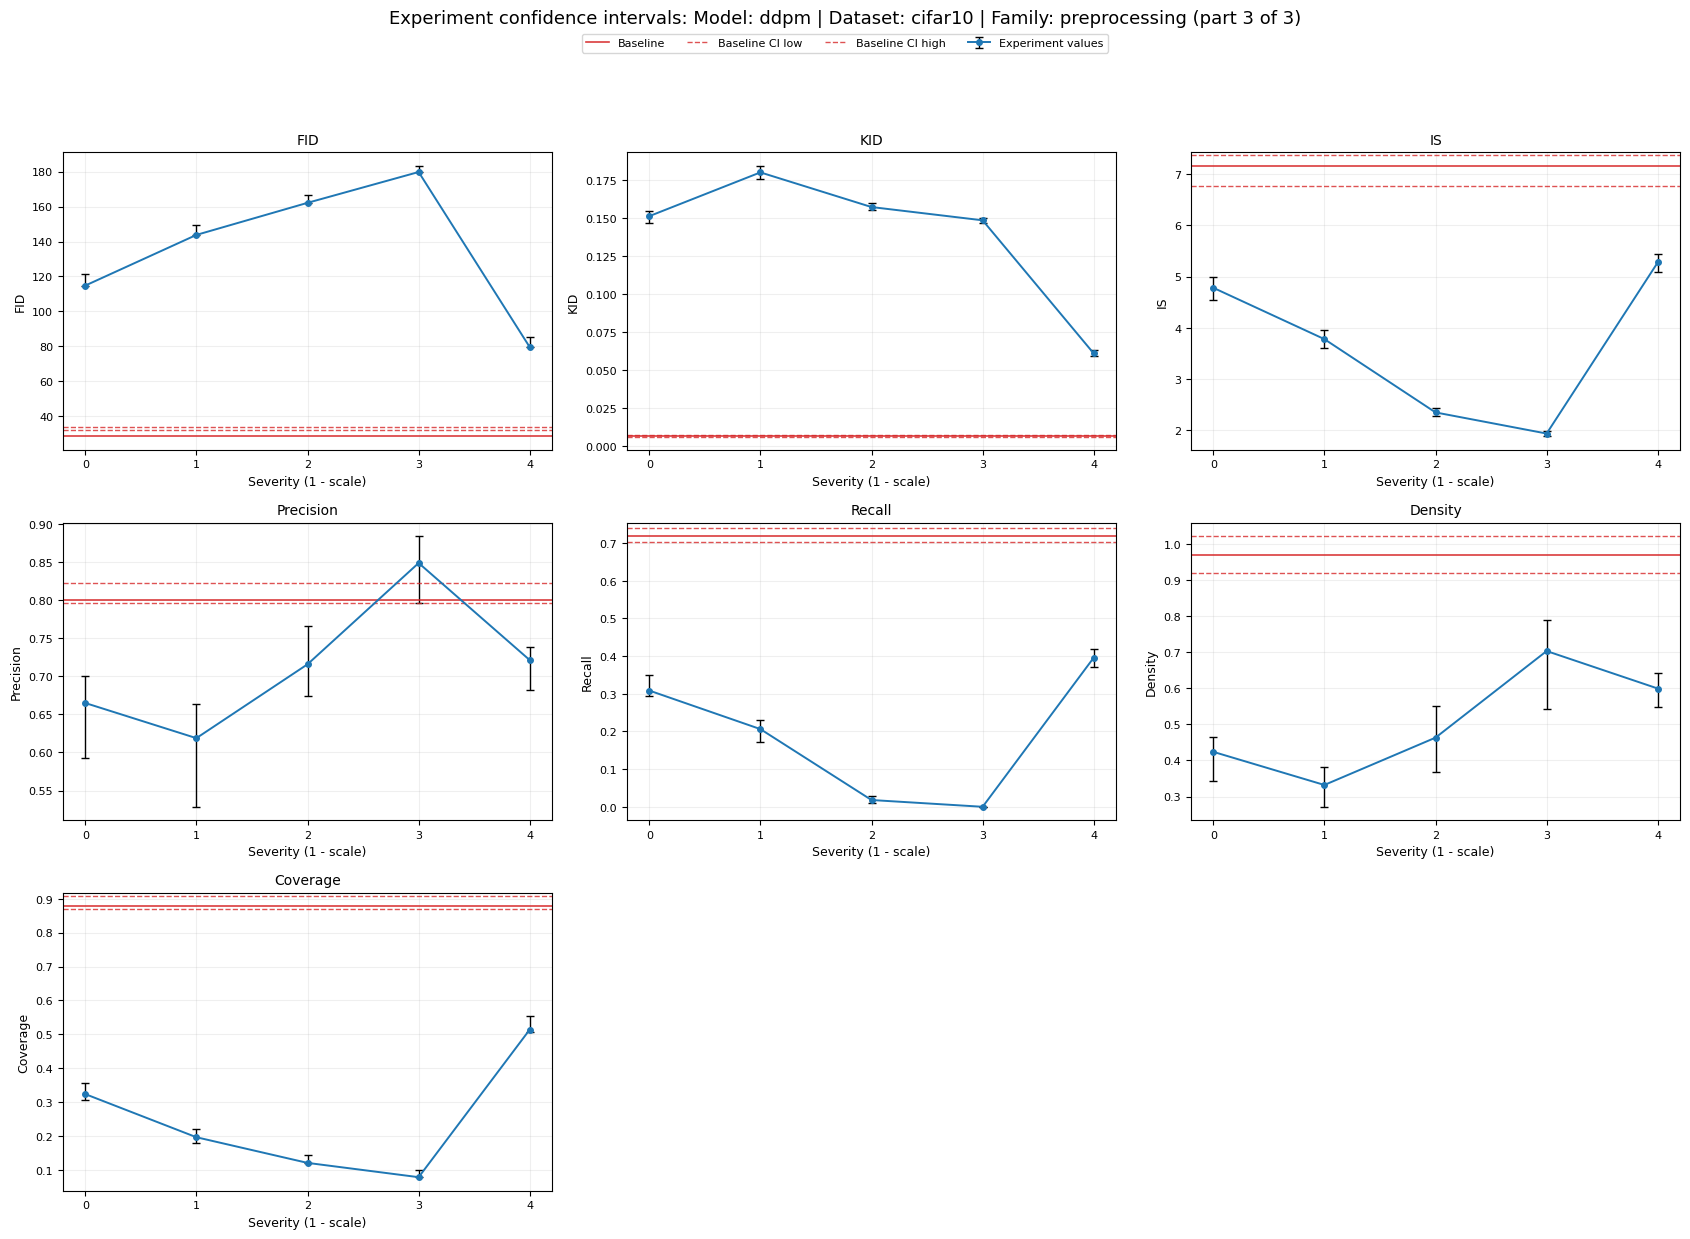

C:\Users\sofia\OneDrive\Desktop\Project_Master_2\Group07_Improving_Metrics\Task3\analysis\ci_visualizations.py:85: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tick_values_sorted[0] * 0.9, tick_values_sorted[-1] * 1.05)
C:\Users\sofia\OneDrive\Desktop\Project_Master_2\Group07_Improving_Metrics\Task3\analysis\ci_visualizations.py:85: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tick_values_sorted[0] * 0.9, tick_values_sorted[-1] * 1.05)
C:\Users\sofia\OneDrive\Desktop\Project_Master_2\Group07_Improving_Metrics\Task3\analysis\ci_visualizations.py:85: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tick_values_sorted[0] * 0.9, tick_values_sorted[-1] * 1.05)
C:\Users\sofia\OneDrive\Desktop\Project_Master_2\Group07_Improving_Metrics\Task3\analysis\ci_visualizations.py:85: UserWarning: Attempt to set non-positive xlim on a log-scaled axis

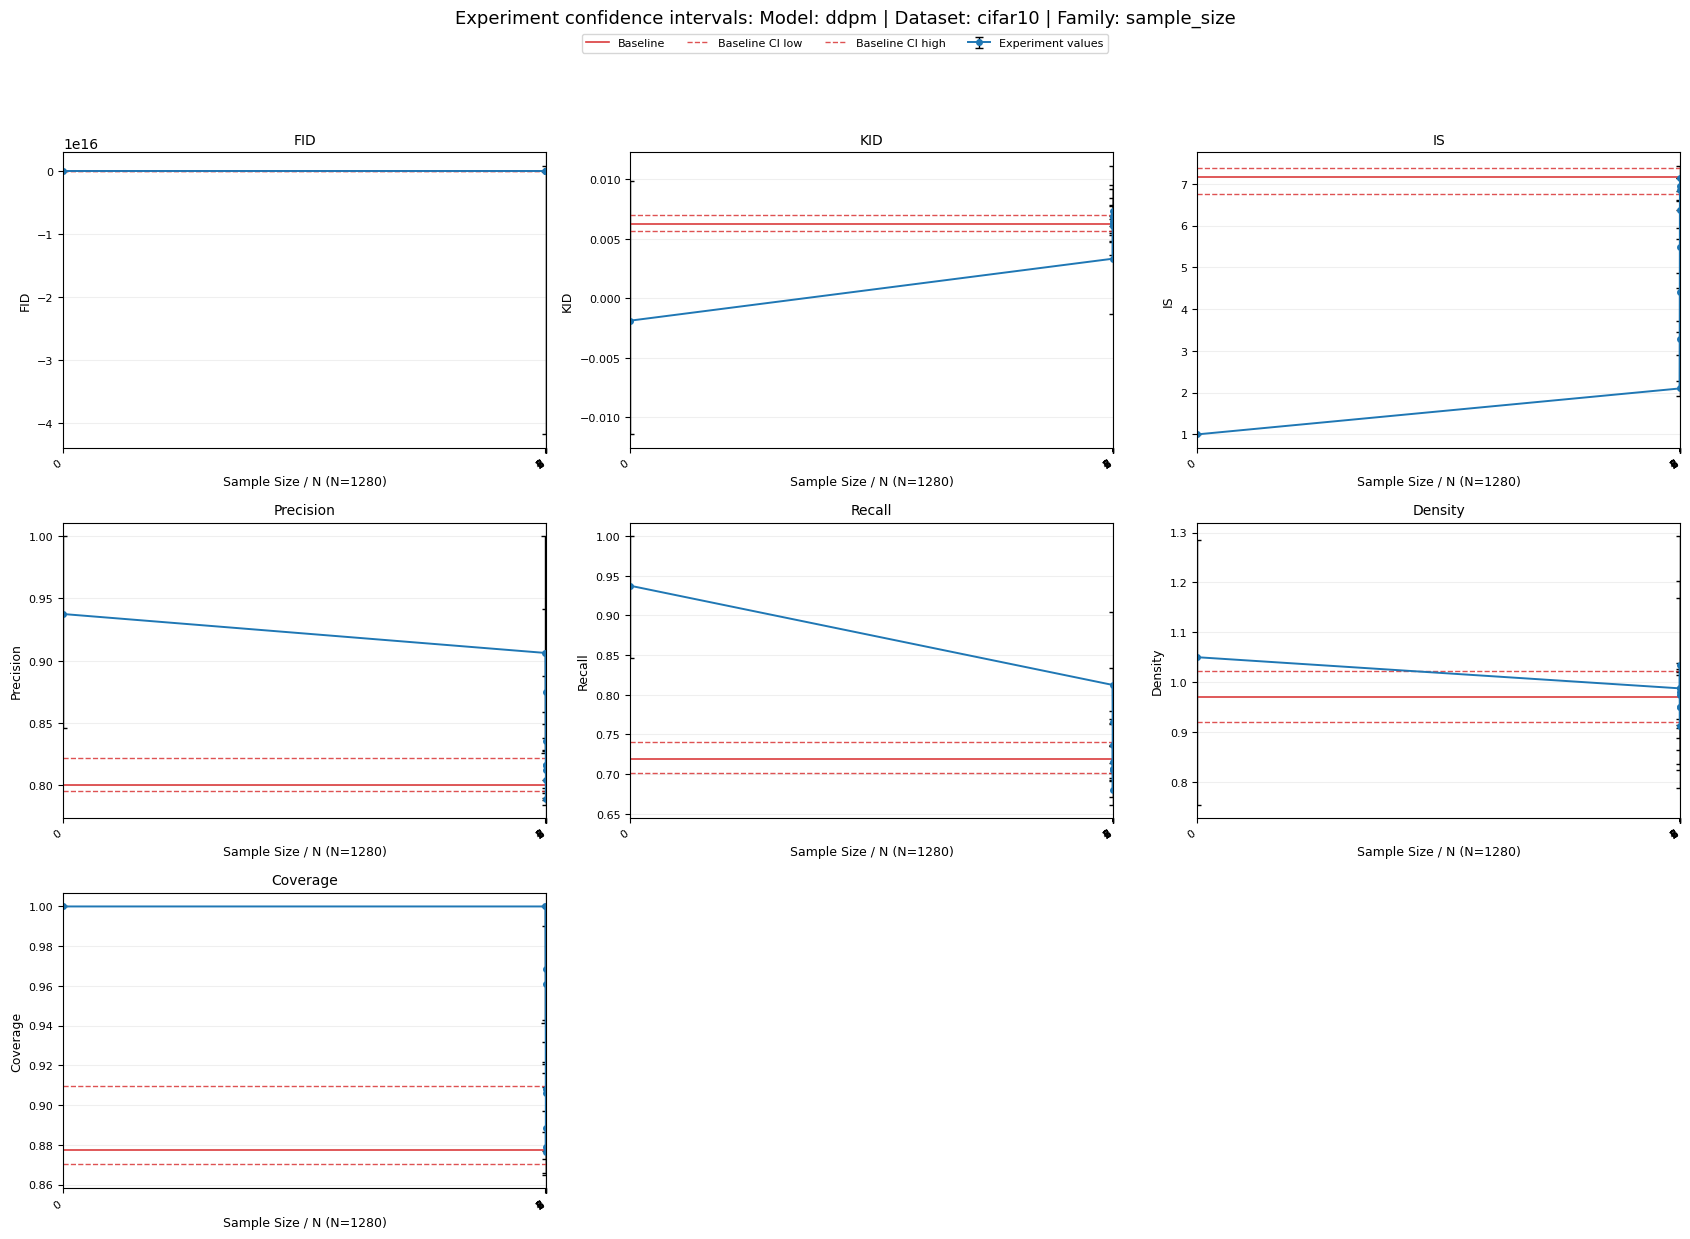

Plotted confidence intervals for 58 non-baseline experiment rows across 8 grouped plot set(s).


,report_file,experiment_id,name,model,dataset,status,exit_code,metrics_expected,metrics_available,step_name,...,recall_ci_high,density_ci_low,density_ci_high,coverage_ci_low,coverage_ci_high,fid_error,kid_error,is_error,pr_error,dc_error
1,seed_01_ddpm_cifar10_perturbation_tests_CI_Angelos.json,degrade_noise_sev1__734165c0f9,degrade_noise_sev1,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.556836,0.504116,0.598428,0.616211,0.659180,,,,,
2,seed_01_ddpm_cifar10_perturbation_tests_CI_Angelos.json,degrade_noise_sev2__86d0d5787d,degrade_noise_sev2,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.160669,0.177334,0.276904,0.164526,0.201685,,,,,
3,seed_01_ddpm_cifar10_perturbation_tests_CI_Angelos.json,degrade_noise_sev3__8930d054c8,degrade_noise_sev3,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.008789,0.170117,0.322490,0.074683,0.092773,,,,,
4,seed_01_ddpm_cifar10_perturbation_tests_CI_Angelos.json,degrade_noise_sev4__86b1579745,degrade_noise_sev4,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.000000,0.095293,0.242187,0.027344,0.036646,,,,,
5,seed_01_ddpm_cifar10_perturbation_tests_CI_Angelos.json,degrade_noise_sev5__f60f1ffecb,degrade_noise_sev5,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.000000,0.002344,0.014165,0.002930,0.006836,,,,,
6,seed_01_ddpm_cifar10_perturbation_tests_CI_Angelos.json,degrade_blur_sev1__05fbea7dcf,degrade_blur_sev1,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.442432,0.830557,0.948208,0.570776,0.617285,,,,,
7,seed_01_ddpm_cifar10_perturbation_tests_CI_Angelos.json,degrade_blur_sev2__9e3b7bc3ec,degrade_blur_sev2,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.007812,0.295356,0.395732,0.170898,0.199219,,,,,
8,seed_01_ddpm_cifar10_perturbation_tests_CI_Angelos.json,degrade_blur_sev3__95b055ca78,degrade_blur_sev3,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.000000,0.104409,0.174111,0.058081,0.074219,,,,,
9,seed_01_ddpm_cifar10_perturbation_tests_CI_Angelos.json,degrade_blur_sev4__9bfa6b7cae,degrade_blur_sev4,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.000000,0.003999,0.020620,0.007812,0.014648,,,,,
10,seed_01_ddpm_cifar10_perturbation_tests_CI_Angelos.json,degrade_blur_sev5__04be9f9fc7,degrade_blur_sev5,ddpm,cifar10,completed,0,True,True,test_ddpm_cifar10,...,0.000000,0.008721,0.072285,0.004370,0.009302,,,,,


In [17]:
filtered_df = df[~df["perturbation_family"].str.startswith("class_imbalance")]
filtered_df = filtered_df[~filtered_df["perturbation_family"].str.startswith("class_removal")]
plot_experiment_confidence_intervals(filtered_df)

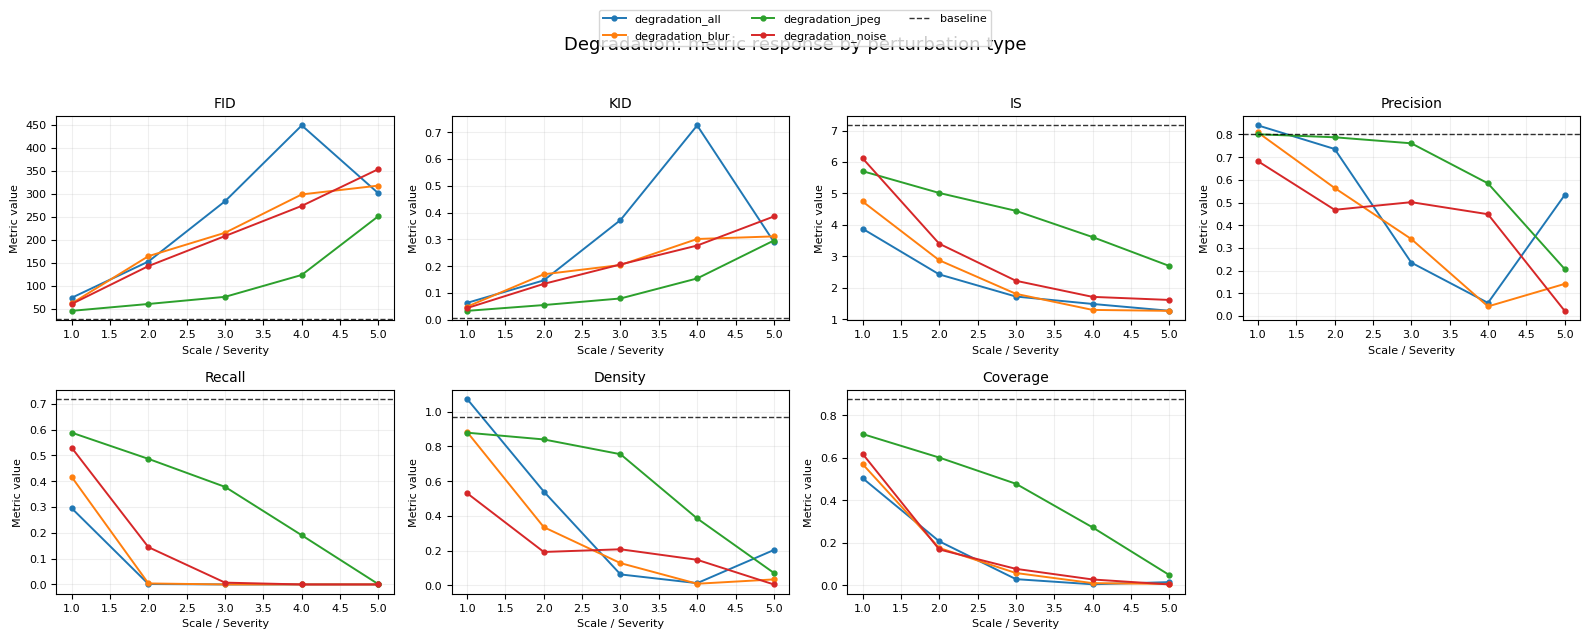

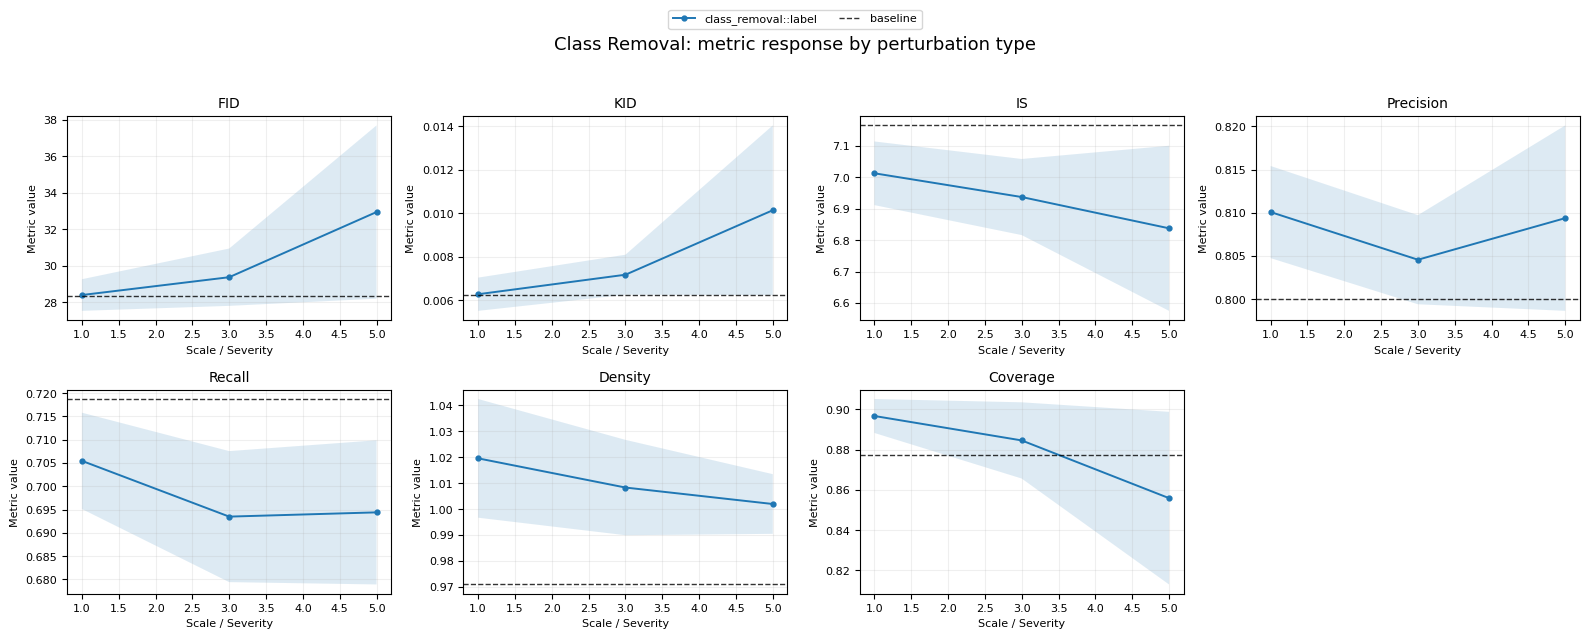

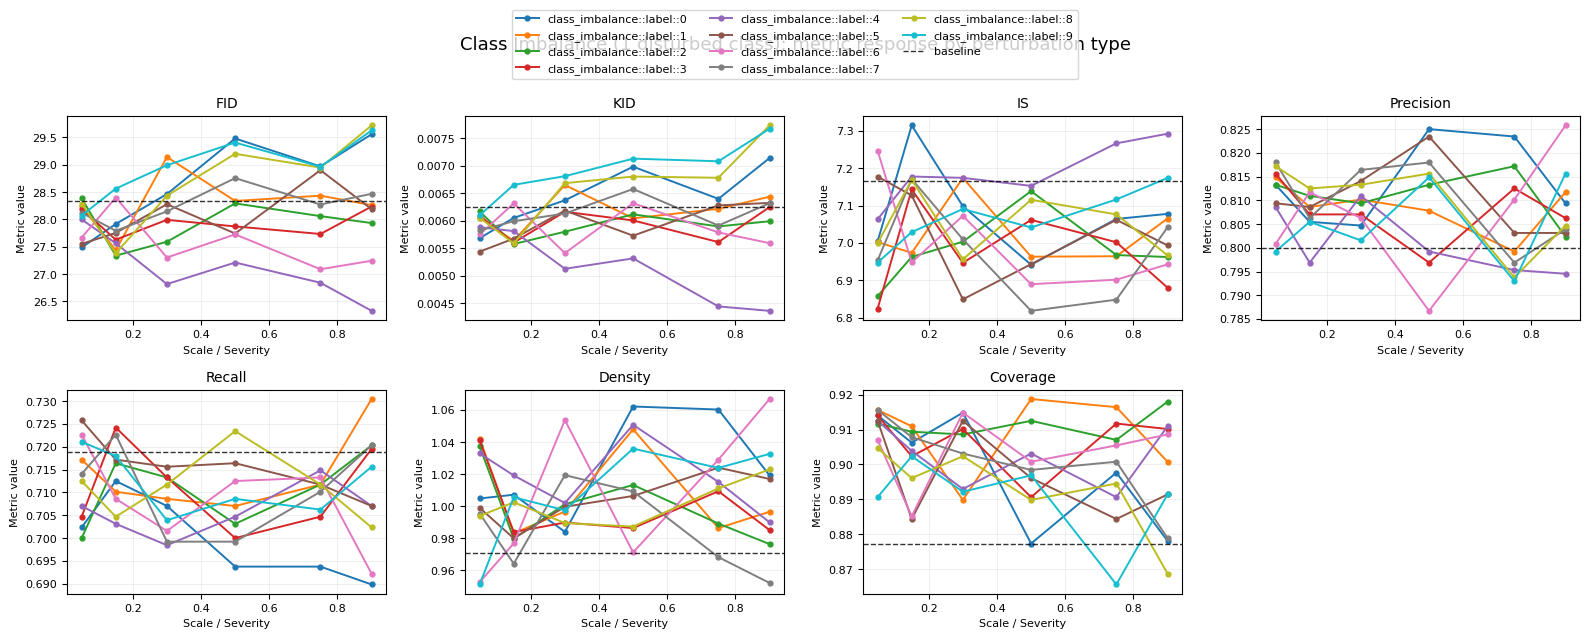

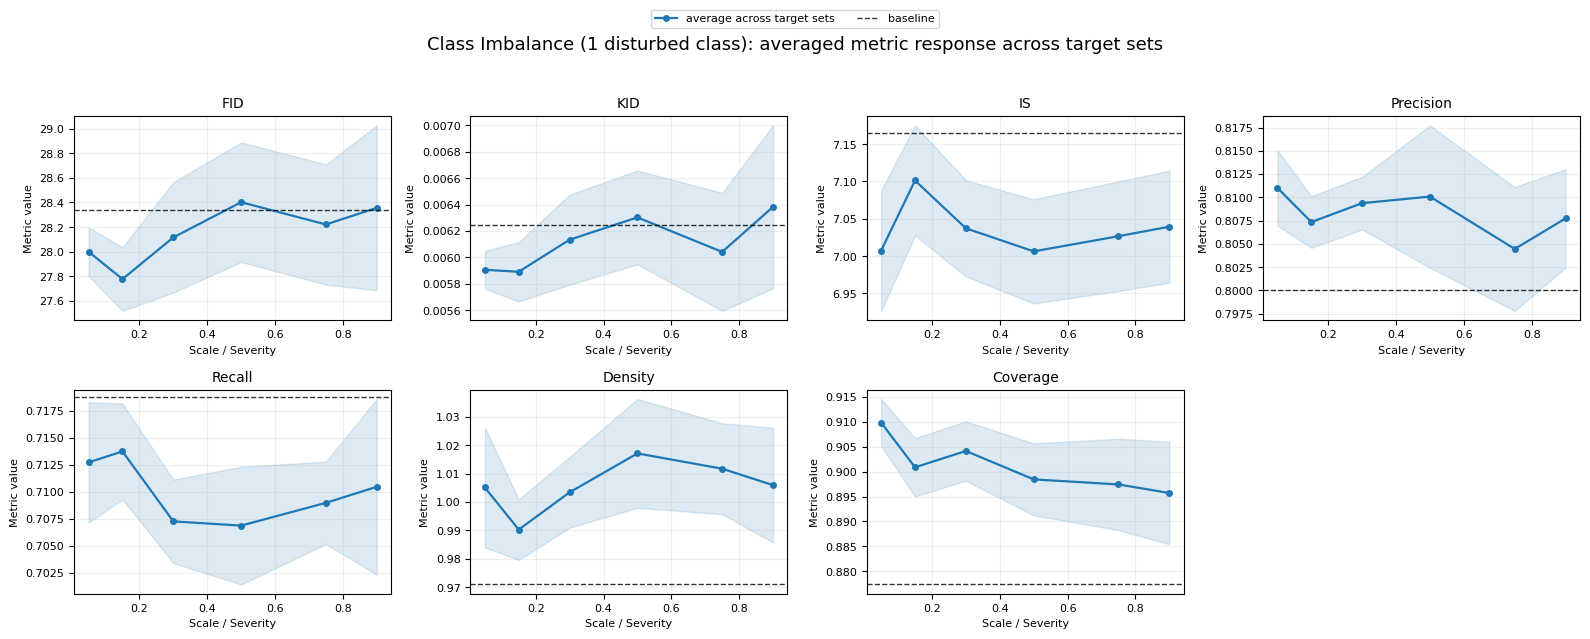

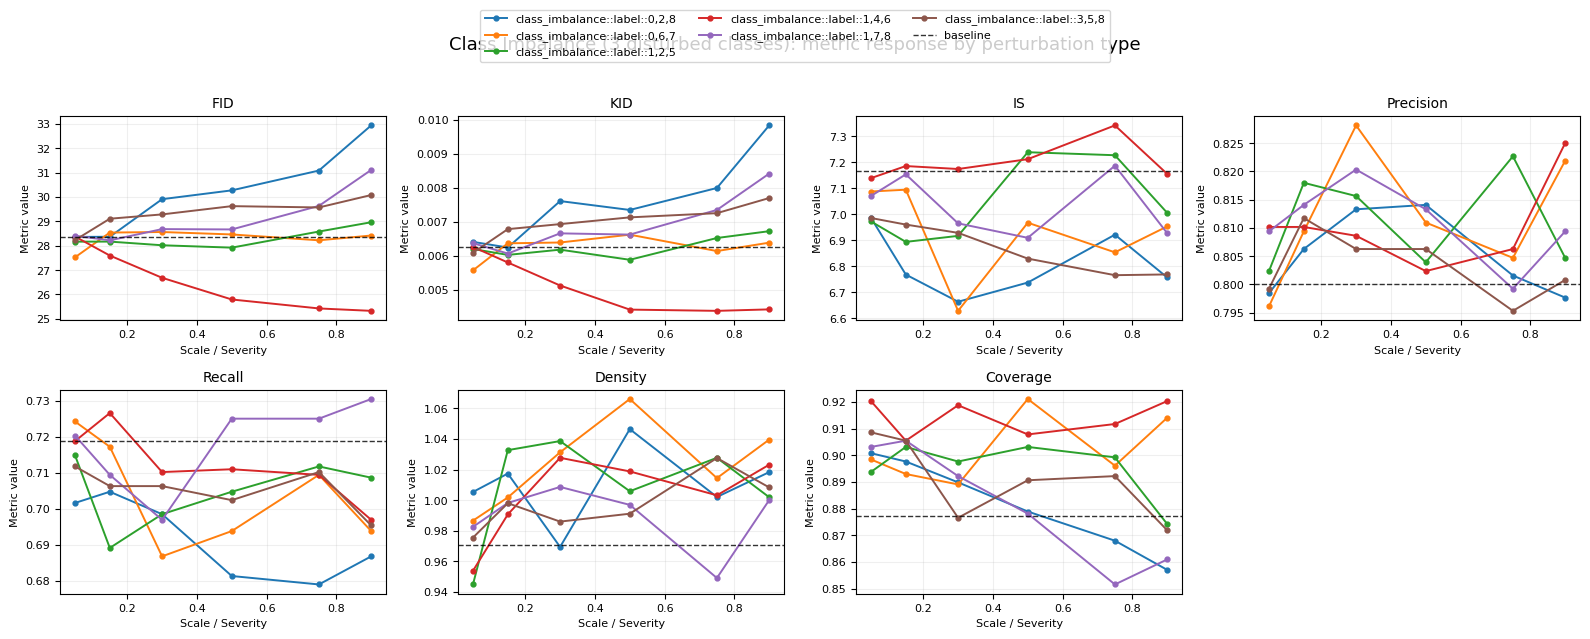

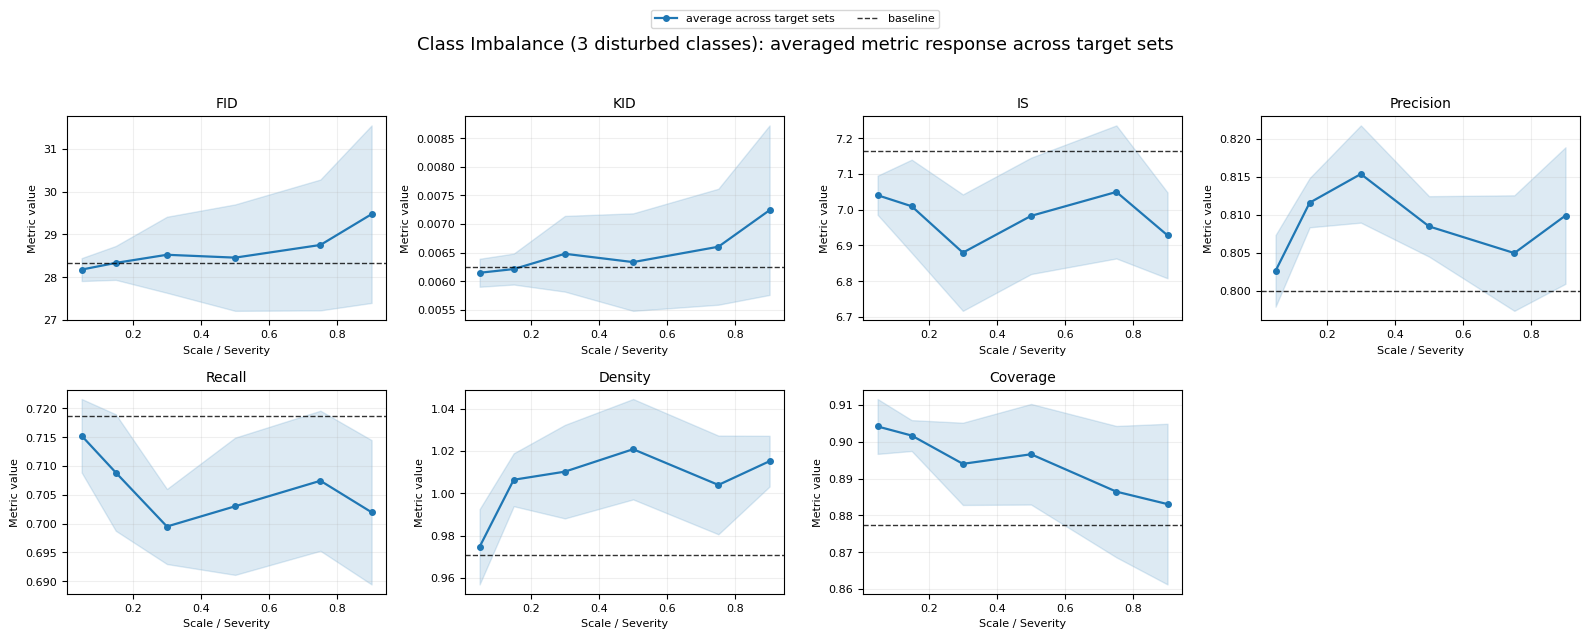

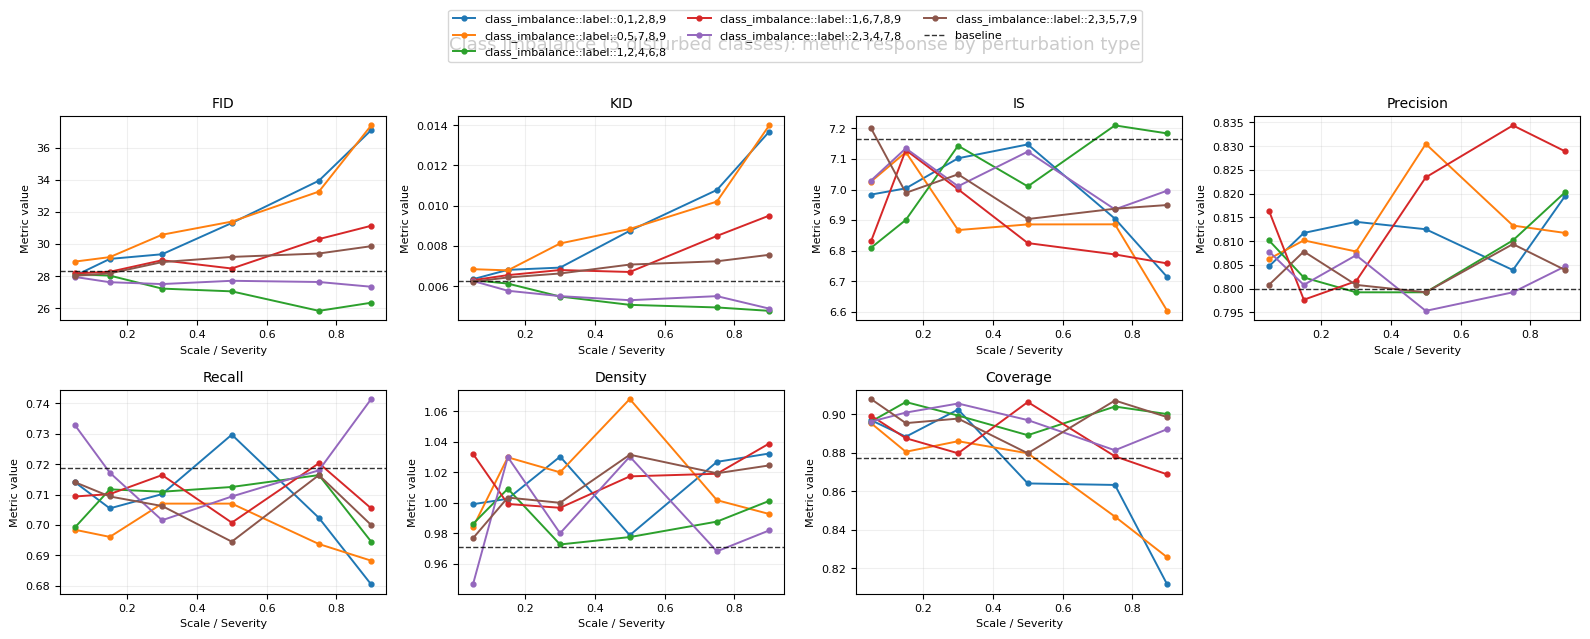

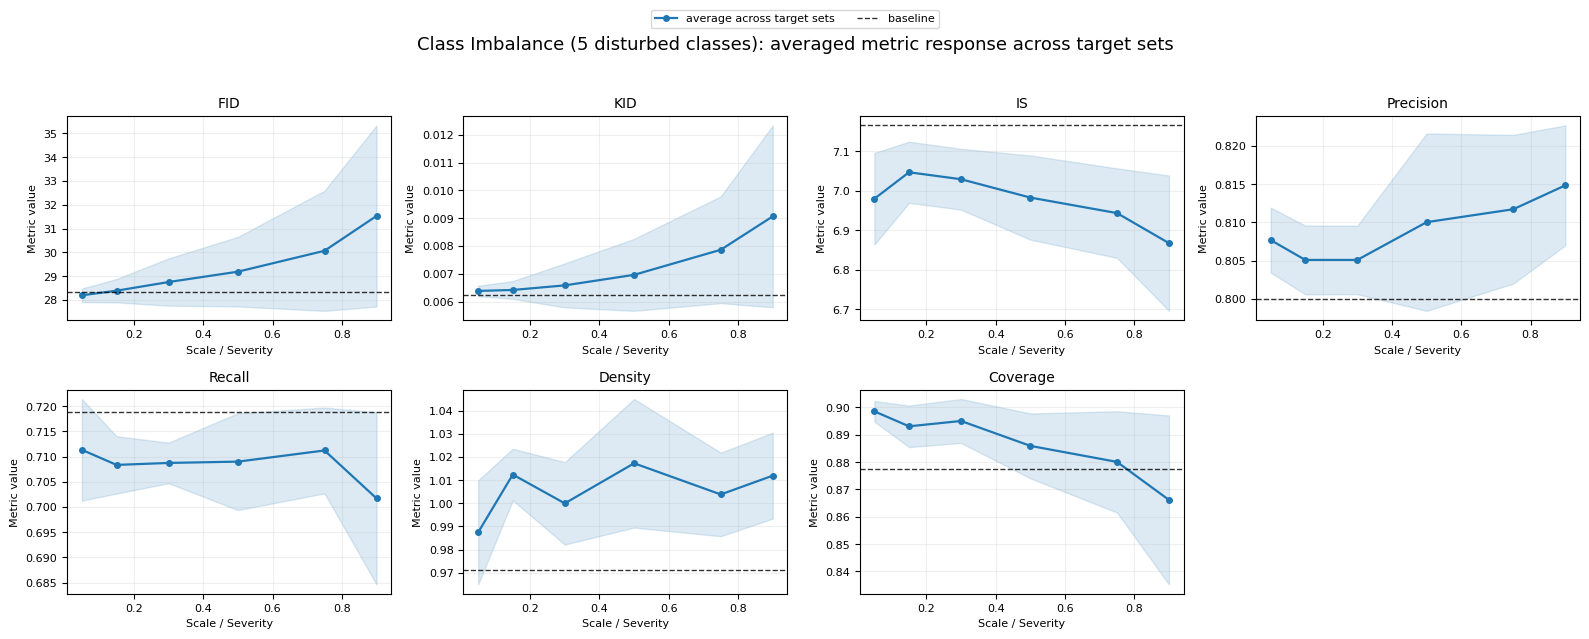

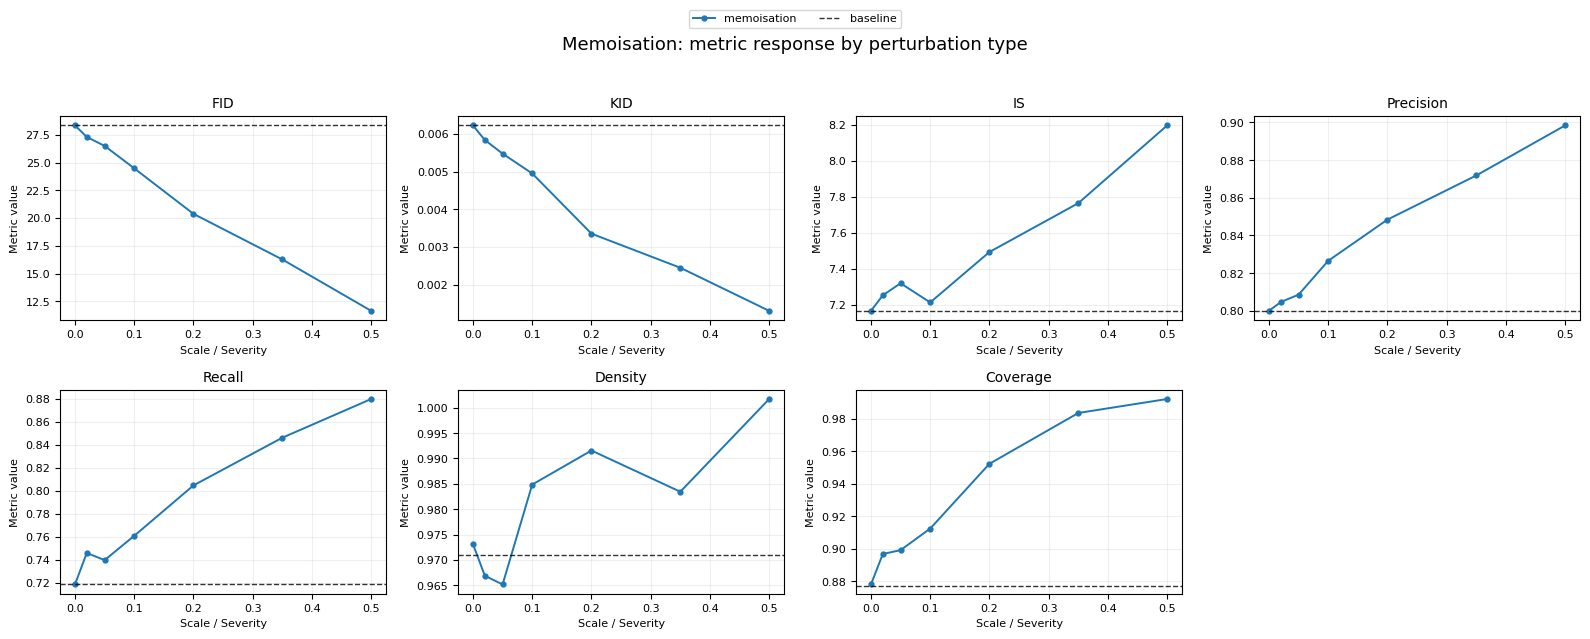

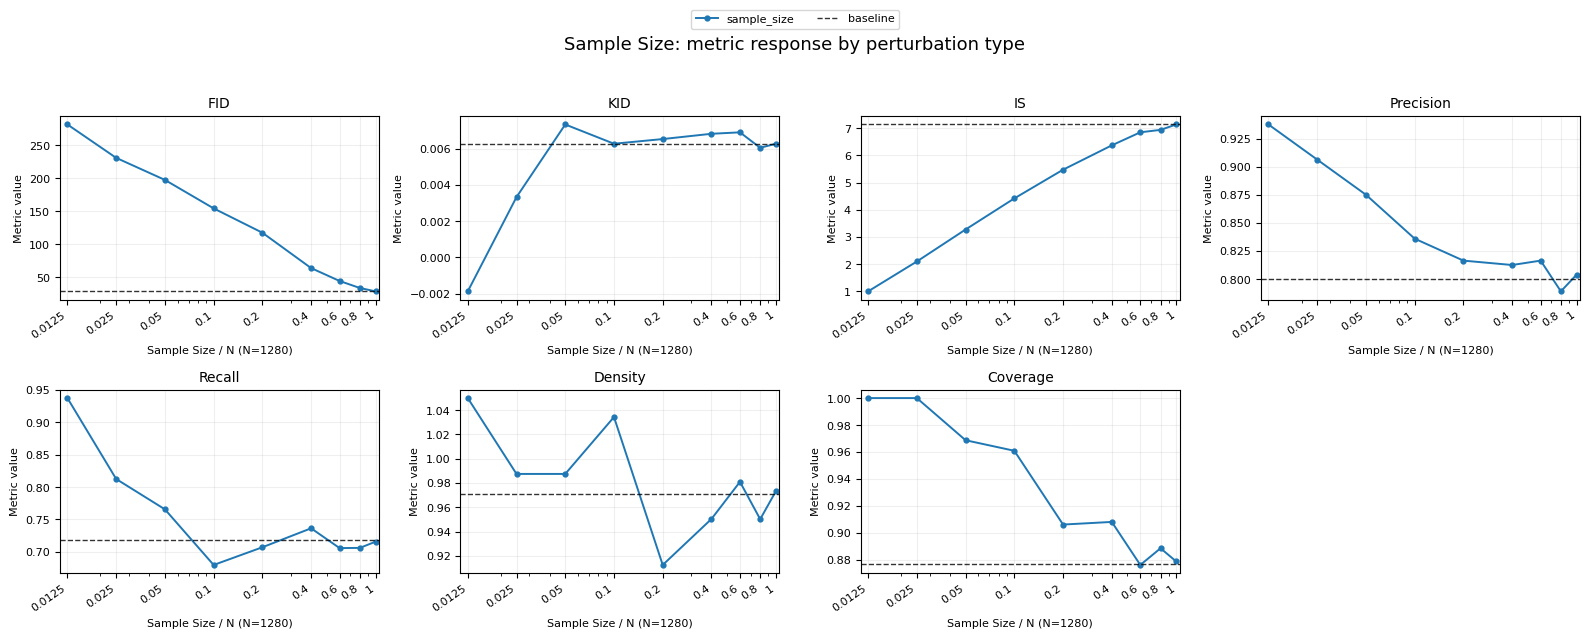

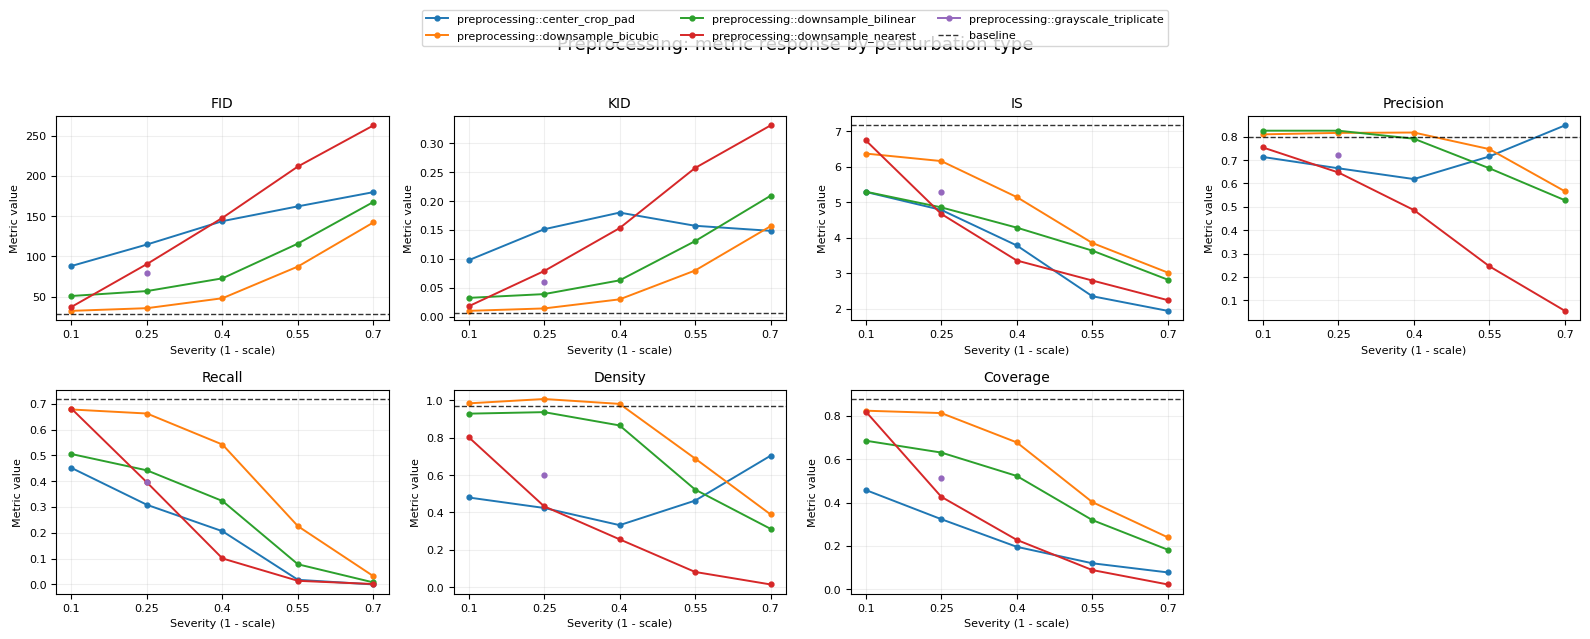

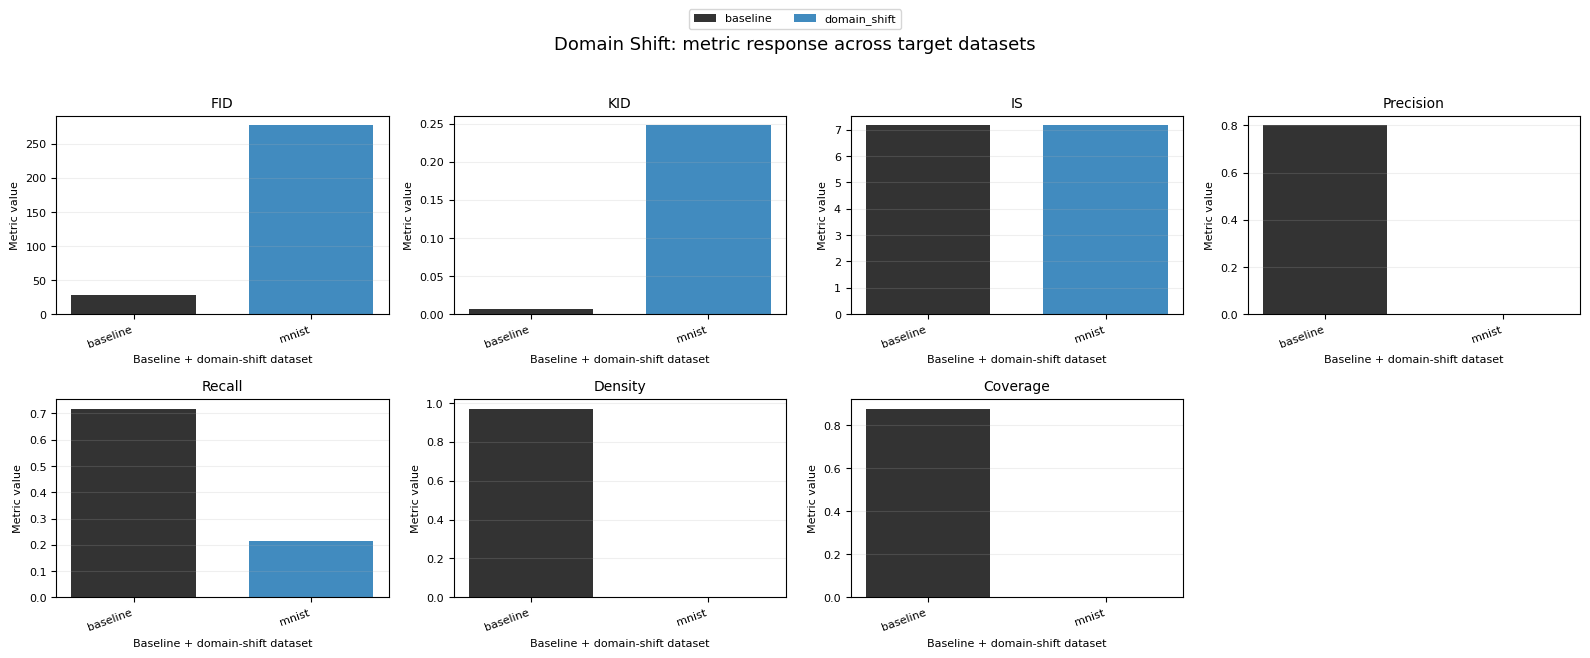

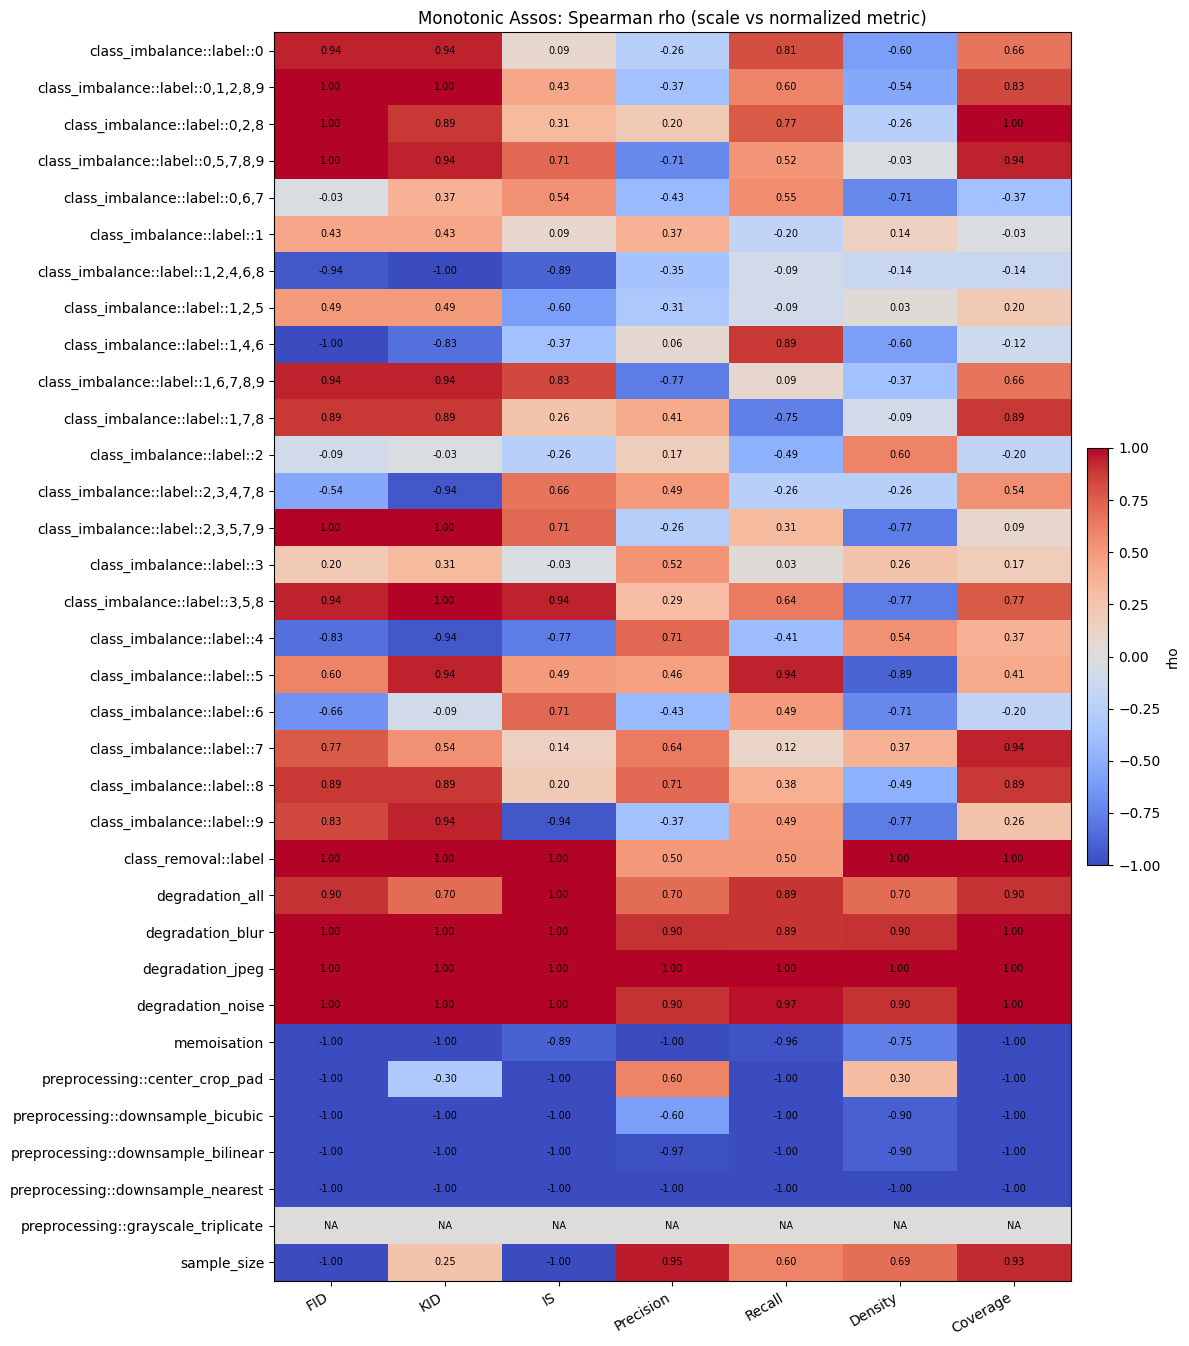

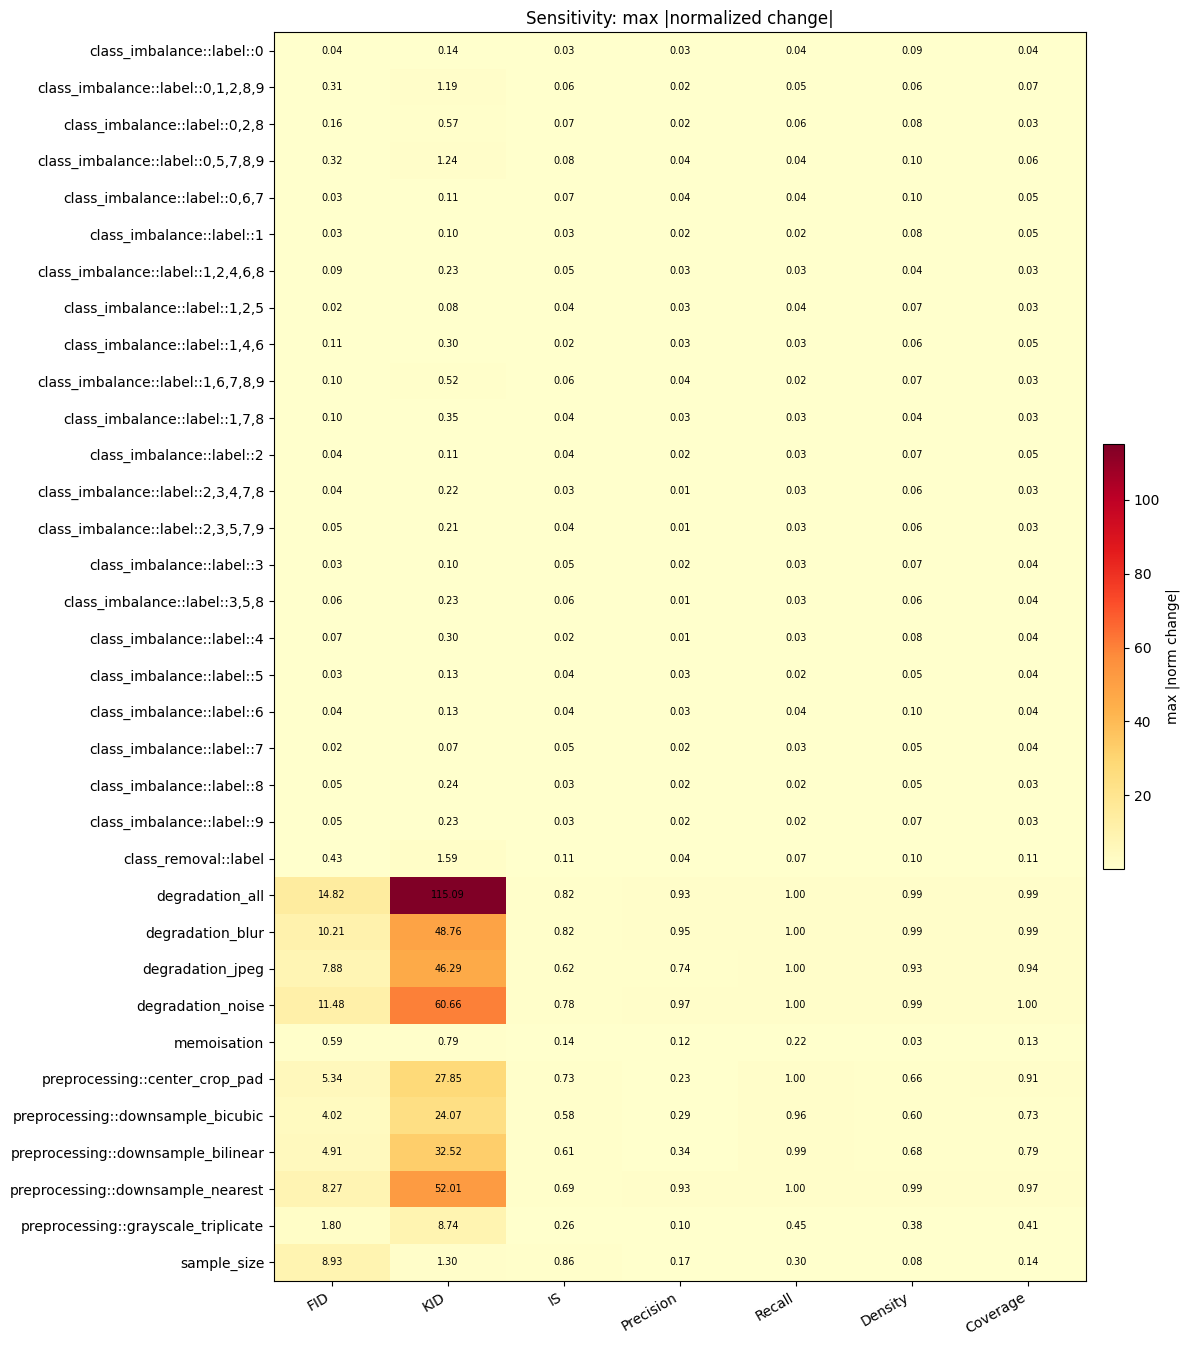

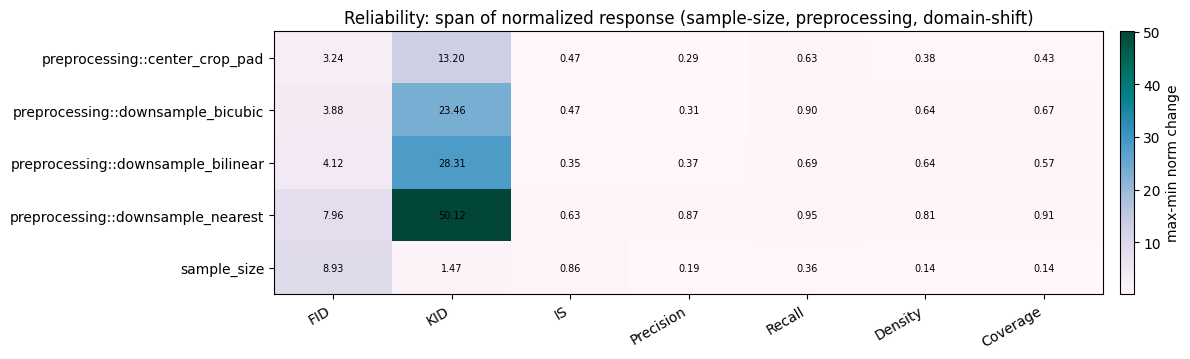

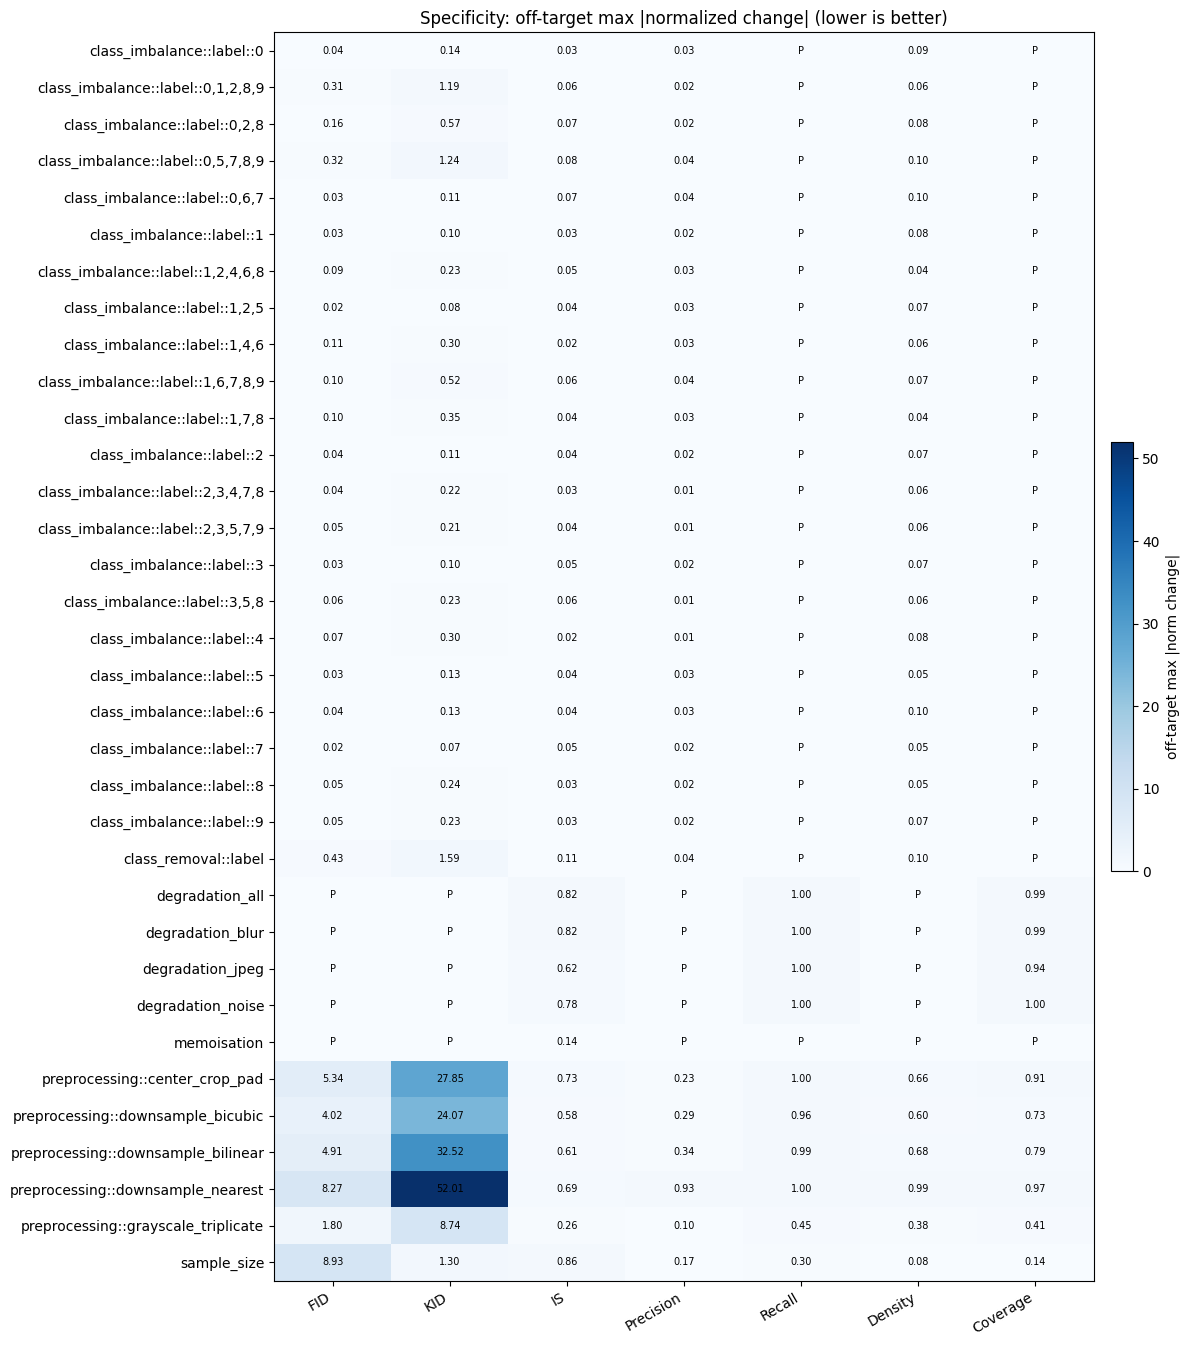

Perturbation groups included in curve analysis:
['class_imbalance::label::0', 'class_imbalance::label::0,1,2,8,9', 'class_imbalance::label::0,2,8', 'class_imbalance::label::0,5,7,8,9', 'class_imbalance::label::0,6,7', 'class_imbalance::label::1', 'class_imbalance::label::1,2,4,6,8', 'class_imbalance::label::1,2,5', 'class_imbalance::label::1,4,6', 'class_imbalance::label::1,6,7,8,9', 'class_imbalance::label::1,7,8', 'class_imbalance::label::2', 'class_imbalance::label::2,3,4,7,8', 'class_imbalance::label::2,3,5,7,9', 'class_imbalance::label::3', 'class_imbalance::label::3,5,8', 'class_imbalance::label::4', 'class_imbalance::label::5', 'class_imbalance::label::6', 'class_imbalance::label::7', 'class_imbalance::label::8', 'class_imbalance::label::9', 'class_removal::label', 'degradation_all', 'degradation_blur', 'degradation_jpeg', 'degradation_noise', 'memoisation', 'preprocessing::center_crop_pad', 'preprocessing::downsample_bicubic', 'preprocessing::downsample_bilinear', 'preprocessin

,name,model,dataset,perturbation_group,intensity,strategy,label_mode,affected_class_count,affected_classes,removed_count,kept_count,survivor_count,evaluation_count,returned_count,pool_count
0,class_removal_label_0,ddpm,cifar10,class_removal::label,1.0,label,single_label,1,airplane,350.0,3490.0,3490.0,1280.0,1280.0,3840.0
1,class_removal_label_1,ddpm,cifar10,class_removal::label,1.0,label,single_label,1,automobile,132.0,3708.0,3708.0,1280.0,1280.0,3840.0
2,class_removal_label_2,ddpm,cifar10,class_removal::label,1.0,label,single_label,1,bird,115.0,3725.0,3725.0,1280.0,1280.0,3840.0
3,class_removal_label_3,ddpm,cifar10,class_removal::label,1.0,label,single_label,1,cat,109.0,3731.0,3731.0,1280.0,1280.0,3840.0
4,class_removal_label_4,ddpm,cifar10,class_removal::label,1.0,label,single_label,1,deer,1254.0,2586.0,2586.0,1280.0,1280.0,3840.0
5,class_removal_label_5,ddpm,cifar10,class_removal::label,1.0,label,single_label,1,dog,270.0,3570.0,3570.0,1280.0,1280.0,3840.0
6,class_removal_label_6,ddpm,cifar10,class_removal::label,1.0,label,single_label,1,frog,616.0,3224.0,3224.0,1280.0,1280.0,3840.0
7,class_removal_label_7,ddpm,cifar10,class_removal::label,1.0,label,single_label,1,horse,196.0,3644.0,3644.0,1280.0,1280.0,3840.0
8,class_removal_label_8,ddpm,cifar10,class_removal::label,1.0,label,single_label,1,ship,244.0,3596.0,3596.0,1280.0,1280.0,3840.0
9,class_removal_label_9,ddpm,cifar10,class_removal::label,1.0,label,single_label,1,truck,554.0,3286.0,3286.0,1280.0,1280.0,3840.0


Class Removal: per-class detail:


,name,model,dataset,perturbation_group,intensity,strategy,label_mode,affected_class_index,affected_class,drop_fraction,affected_pool_count,exact_removed_count_if_available,count_kind
0,class_removal_label_0,ddpm,cifar10,class_removal::label,1.0,label,single_label,0,airplane,NaN,350.0,350.0,predicted_label_histogram_fake
1,class_removal_label_1,ddpm,cifar10,class_removal::label,1.0,label,single_label,1,automobile,NaN,132.0,132.0,predicted_label_histogram_fake
2,class_removal_label_2,ddpm,cifar10,class_removal::label,1.0,label,single_label,2,bird,NaN,115.0,115.0,predicted_label_histogram_fake
3,class_removal_label_3,ddpm,cifar10,class_removal::label,1.0,label,single_label,3,cat,NaN,109.0,109.0,predicted_label_histogram_fake
4,class_removal_label_4,ddpm,cifar10,class_removal::label,1.0,label,single_label,4,deer,NaN,1254.0,1254.0,predicted_label_histogram_fake
5,class_removal_label_5,ddpm,cifar10,class_removal::label,1.0,label,single_label,5,dog,NaN,270.0,270.0,predicted_label_histogram_fake
6,class_removal_label_6,ddpm,cifar10,class_removal::label,1.0,label,single_label,6,frog,NaN,616.0,616.0,predicted_label_histogram_fake
7,class_removal_label_7,ddpm,cifar10,class_removal::label,1.0,label,single_label,7,horse,NaN,196.0,196.0,predicted_label_histogram_fake
8,class_removal_label_8,ddpm,cifar10,class_removal::label,1.0,label,single_label,8,ship,NaN,244.0,244.0,predicted_label_histogram_fake
9,class_removal_label_9,ddpm,cifar10,class_removal::label,1.0,label,single_label,9,truck,NaN,554.0,554.0,predicted_label_histogram_fake


Class Imbalance: removed-image overview:


...

Reliability (head):


,perturbation_group,metric,n_points,mean_norm,std_norm,cv_norm,span_norm
13,preprocessing::center_crop_pad,coverage,5,0.731968,0.158546,0.216602,0.432769
12,preprocessing::center_crop_pad,density,5,0.504892,0.126501,0.250551,0.383006
7,preprocessing::center_crop_pad,fid,5,3.858679,1.159795,0.300568,3.238377
9,preprocessing::center_crop_pad,is_mean,5,0.493619,0.183109,0.370953,0.467827
8,preprocessing::center_crop_pad,kid_mean,5,22.540809,4.330740,0.192129,13.203007
10,preprocessing::center_crop_pad,precision,5,0.109766,0.096094,0.875448,0.287109
11,preprocessing::center_crop_pad,recall,5,0.726087,0.239532,0.329895,0.628261
20,preprocessing::downsample_bicubic,coverage,5,0.326269,0.264595,0.810972,0.665183
19,preprocessing::downsample_bicubic,density,5,0.165465,0.248140,1.499655,0.636466
14,preprocessing::downsample_bicubic,fid,5,1.436843,1.463530,1.018573,3.878286


Specificity (head):


,perturbation_group,metric,off_target_max_abs_norm,off_target_mean_abs_norm,specificity_kind
6,class_imbalance::label::0,coverage,0.000000,0.000000,primary_metric
5,class_imbalance::label::0,density,0.093981,0.053589,off_target
0,class_imbalance::label::0,fid,0.042882,0.025776,off_target
2,class_imbalance::label::0,is_mean,0.031228,0.018384,off_target
1,class_imbalance::label::0,kid_mean,0.142788,0.070981,off_target
3,class_imbalance::label::0,precision,0.031250,0.016927,off_target
4,class_imbalance::label::0,recall,0.000000,0.000000,primary_metric
13,"class_imbalance::label::0,1,2,8,9",coverage,0.000000,0.000000,primary_metric
12,"class_imbalance::label::0,1,2,8,9",density,0.063244,0.041948,off_target
7,"class_imbalance::label::0,1,2,8,9",fid,0.309127,0.114124,off_target


{'monotonicity':             perturbation_group     metric  rho_spearman   p_value   abs_rho
 0    class_imbalance::label::0        fid      0.942857  0.004805  0.942857
 1    class_imbalance::label::0   kid_mean      0.942857  0.004805  0.942857
 2    class_imbalance::label::0    is_mean      0.085714  0.871743  0.085714
 3    class_imbalance::label::0  precision     -0.257143  0.622787  0.257143
 4    class_imbalance::label::0     recall      0.811679  0.049858  0.811679
 ..                         ...        ...           ...       ...       ...
 233                sample_size    is_mean     -1.000000  0.000000  1.000000
 234                sample_size  precision      0.953983  0.000066  0.953983
 235                sample_size     recall      0.600000  0.087623  0.600000
 236                sample_size    density      0.694567  0.037864  0.694567
 237                sample_size   coverage      0.928878  0.000295  0.928878
 
 [238 rows x 5 columns],
 'sensitivity':             pertu

In [8]:
run_full_perturbation_analysis(df)
